# Phase 2: Bivariate and Multivariate Analysis

**Project:** CogniLend – Loan Approval Decision-Support System
**Input:** `data/raw/loan_applications_raw.csv` and the Phase 1 report (`phase1/preprocessing_phase1_report.md`)
**Output:** `phase2/preprocessing_phase2_report.md` and the plots in `phase2/plots/`

**Aim of this phase:** study how columns are **related** to each other and to the target (Loan_Status).

**Rule for this phase:** same as Phase 1. We only **study** the data. The real data frame `df` is never changed.
For plotting we use a **temporary copy** (`plot_df`) with only the basic fixes that Phase 1 already used for plots
(joined spellings, Loan_Amount text → number, impossible values hidden). No duplicates are removed, nothing is filled,
and no new feature is created. Those are Phase 3 and Phase 4 jobs.

**What we take from Phase 1**
- The issue IDs **P01–P18** (we update their status at the end).
- The 9 **questions for Phase 2** (answered in Part A).
- `valid_range`, `valid_categories` and `plot_map` (copied below).

## Step 0: Import libraries and load the data

In [1]:
import os
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

# same colours as Phase 1
MAIN_COLOR = '#2a78d6'      # blue   -> Approved / normal bars
SECOND_COLOR = '#eb6834'    # orange -> Rejected / problem
THIRD_COLOR = '#1baf7a'     # green  -> third group (only when 3 groups are needed)
MISSING_COLOR = '#b5b5b5'   # grey   -> missing / blank
STATUS_COLORS = {'Approved': MAIN_COLOR, 'Rejected': SECOND_COLOR}

sns.set_style('whitegrid')
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['grid.color'] = '#e6e6e6'
plt.rcParams['axes.edgecolor'] = '#999999'

PLOT_DIR = 'plots'
os.makedirs(PLOT_DIR, exist_ok=True)


def save_plot(file_name):
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, file_name), dpi=150, bbox_inches='tight')
    plt.show()

In [2]:
DATA_PATH = '../data/raw/loan_applications_raw.csv'
df = pd.read_csv(DATA_PATH)
print('Data loaded:', df.shape)

Data loaded: (10000, 17)


## Step 1: Settings copied from Phase 1

In [3]:
# copied from Phase 1 (Part A) - valid values from domain knowledge
valid_range = {
    'Age':                (18, 75),
    'Work_Experience':    (0, 50),
    'Monthly_Income':     (1, None),
    'Coapplicant_Income': (1, None),
    'Existing_EMI':       (0, None),
    'CIBIL_Score':        (300, 900),     # -1 is also allowed (no credit history)
    'Loan_Amount':        (1, None),
    'Loan_Tenure':        (6, 360),
    'Collateral_Value':   (1, None),
}

# copied from Phase 1 (Part C2) - joins spellings that mean the same thing
plot_map = {
    'Gender': {'male': 'Male', 'm': 'Male', 'female': 'Female', 'f': 'Female',
               'transgender': 'Transgender', 'tg': 'Transgender'},
    'Marital_Status': {'married': 'Married', 'single': 'Single', 'unmarried': 'Single',
                       'divorced': 'Divorced', 'widowed': 'Widowed'},
    'Employment_Type': {'salaried': 'Salaried', 'service': 'Salaried',
                        'self-employed professional': 'SEP', 'self employed professional': 'SEP', 'sep': 'SEP',
                        'self-employed non-professional': 'SENP', 'self employed business': 'SENP',
                        'business owner': 'SENP', 'senp': 'SENP'},
    'Loan_Type': {'home loan': 'Home', 'housing loan': 'Home', 'hl': 'Home',
                  'vehicle loan': 'Vehicle', 'auto loan': 'Vehicle', 'car loan': 'Vehicle',
                  'personal loan': 'Personal', 'personal': 'Personal', 'pl': 'Personal',
                  'business loan': 'Business', 'msme loan': 'Business', 'bl': 'Business'},
    'Property_Area': {'urban': 'Urban', 'semi-urban': 'Semi-Urban', 'semi urban': 'Semi-Urban',
                      'semiurban': 'Semi-Urban', 'rural': 'Rural'},
}
# short names are used in plots: SEP = Self-Employed Professional, SENP = Self-Employed Non-Professional
order = {
    'Gender': ['Male', 'Female', 'Transgender'],
    'Marital_Status': ['Married', 'Single', 'Divorced', 'Widowed'],
    'Dependents': ['0', '1', '2', '3+'],
    'Employment_Type': ['Salaried', 'SEP', 'SENP'],
    'Loan_Type': ['Home', 'Vehicle', 'Personal', 'Business'],
    'Property_Area': ['Urban', 'Semi-Urban', 'Rural'],
}

## Step 2: Make the temporary plotting copy

`plot_df` is used **only for plots and tables in this notebook**. It is never saved.

| Basic fix (plotting only) | Why |
|---|---|
| Join spellings with `plot_map` | So that `HL` and `Home Loan` are one group |
| Loan_Amount text → number | So it can be plotted (Phase 1 showed no value is lost) |
| Impossible values → blank (Age, Work_Experience, Monthly_Income ≤ 0, CIBIL outside 300–900 except −1) | So they do not spoil the plots |
| `approved` = 1 / 0 from Loan_Status | So we can calculate approval rate (%) |

**Not done here (on purpose):** removing duplicates, filling missing values, fixing tenure units, creating new features.

In [4]:
plot_df = df.copy()

# 1. join spellings
for col in plot_map:
    plot_df[col] = plot_df[col].str.strip().str.lower().map(plot_map[col])

# 2. Loan_Amount text -> number
amount = plot_df['Loan_Amount'].str.replace('Rs.', '', regex=False)
amount = amount.str.replace(',', '', regex=False).str.strip()
plot_df['Loan_Amount'] = pd.to_numeric(amount, errors='coerce')

# 3. hide impossible values (only in this copy)
for col in ['Age', 'Work_Experience', 'Monthly_Income']:
    low = valid_range[col][0]
    high = valid_range[col][1]
    if high is None:
        bad = plot_df[col] < low
    else:
        bad = (plot_df[col] < low) | (plot_df[col] > high)
    print(col, '-> hidden for plots:', bad.sum())
    plot_df.loc[bad, col] = np.nan

bad_cibil = (plot_df['CIBIL_Score'] != -1) & ((plot_df['CIBIL_Score'] < 300) | (plot_df['CIBIL_Score'] > 900))
print('CIBIL_Score -> hidden for plots:', bad_cibil.sum())
plot_df.loc[bad_cibil, 'CIBIL_Score'] = np.nan

# 4. target as 1/0 (blank target stays blank)
plot_df['approved'] = plot_df['Loan_Status'].map({'Approved': 1, 'Rejected': 0})

OVERALL_RATE = plot_df['approved'].mean() * 100
print()
print('Rows with a target:', plot_df['approved'].notnull().sum())
print('Overall approval rate: %.2f%%' % OVERALL_RATE)

Age -> hidden for plots: 29
Work_Experience -> hidden for plots: 25
Monthly_Income -> hidden for plots: 30
CIBIL_Score -> hidden for plots: 33

Rows with a target: 9982
Overall approval rate: 58.49%


**Note:** 9,982 rows have a target. The **overall approval rate is 58.49%**. This is the dashed line in all approval-rate plots.
The 135 duplicate rows (P01) are still inside. They are only 1.35% of the data, so they do not change any conclusion below.

**Helper functions used in many plots**

In [5]:
def draw_approval_bars(ax, groups, title, group_order=None, color=MAIN_COLOR):
    # bar chart of approval rate (%) for each group, with the number of rows under each bar
    table = plot_df.groupby(groups, observed=True)['approved'].agg(['mean', 'count'])
    if group_order is not None:
        table = table.reindex(group_order)
    labels = []
    for name, n in zip(table.index, table['count']):
        labels.append(textwrap.fill(str(name), 12) + '\n(n=' + str(int(n)) + ')')
    rates = table['mean'] * 100
    bars = ax.bar(labels, rates, color=color, width=0.6)
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width() / 2, rate + 1.5, str(round(rate, 1)) + '%', ha='center', fontsize=9)
    ax.axhline(OVERALL_RATE, color='#555555', linestyle='--', linewidth=1,
               label='overall approval ' + str(round(OVERALL_RATE, 1)) + '%')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_ylim(0, 100)
    ax.set_ylabel('Approval rate (%)')
    ax.set_title(title)
    ax.xaxis.grid(False)
    return table


def approval_heatmap(row_groups, col_groups, title, file_name, row_order=None, col_order=None, figsize=(8, 4.5)):
    # heatmap: approval rate (%) for every pair of groups, with the row count in brackets
    rate = pd.crosstab(row_groups, col_groups, values=plot_df['approved'], aggfunc='mean') * 100
    count = pd.crosstab(row_groups, col_groups, values=plot_df['approved'], aggfunc='count')
    if row_order is not None:
        rate = rate.reindex(row_order)
        count = count.reindex(row_order)
    if col_order is not None:
        rate = rate[col_order]
        count = count[col_order]
    labels = rate.round(1).astype(str) + '%\n(n=' + count.fillna(0).astype(int).astype(str) + ')'
    labels = labels.where(count.fillna(0) > 0, '')
    plt.figure(figsize=figsize)
    sns.heatmap(rate, annot=labels, fmt='', cmap='Blues', vmin=0, vmax=100,
                linewidths=0.5, cbar_kws={'label': 'approval rate (%)'}, annot_kws={'fontsize': 8})
    plt.yticks(rotation=0)
    plt.grid(False)
    plt.title(title)
    save_plot(file_name)
    return rate.round(1)

## Part A: Answers to the questions from Phase 1

The Phase 1 report (Section 6) left 9 questions that need two or more columns. Questions 1–6 are about **data quality** and are answered here.
Questions 7–9 are about **relationships with the target** and are answered in Parts B and D.

### A1. Coapplicant_Income blanks (P14): does a blank mean "no co-applicant"?

% of rows with blank Coapplicant_Income
Loan_Type
Home        40.8
Vehicle     76.0
Personal    87.2
Business    64.7
Name: Coapplicant_Income, dtype: float64

Marital_Status
Married     62.9
Single      83.0
Divorced    85.3
Widowed     75.9
Name: Coapplicant_Income, dtype: float64

Smallest present value: 4600.0 | rows with value 0: 0


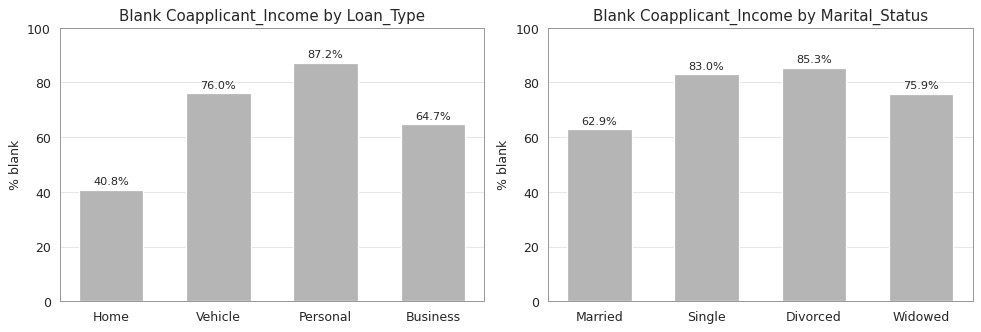

In [6]:
co_blank = plot_df['Coapplicant_Income'].isnull()

blank_by_type = (co_blank.groupby(plot_df['Loan_Type']).mean() * 100).reindex(order['Loan_Type']).round(1)
blank_by_marital = (co_blank.groupby(plot_df['Marital_Status']).mean() * 100).reindex(order['Marital_Status']).round(1)
print('% of rows with blank Coapplicant_Income')
print(blank_by_type)
print()
print(blank_by_marital)
print()
print('Smallest present value:', plot_df['Coapplicant_Income'].min(), '| rows with value 0:', (plot_df['Coapplicant_Income'] == 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar(blank_by_type.index, blank_by_type.values, color=MISSING_COLOR, width=0.6)
axes[0].set_title('Blank Coapplicant_Income by Loan_Type')
axes[1].bar(blank_by_marital.index, blank_by_marital.values, color=MISSING_COLOR, width=0.6)
axes[1].set_title('Blank Coapplicant_Income by Marital_Status')
for ax, values in [(axes[0], blank_by_type), (axes[1], blank_by_marital)]:
    for i in range(len(values)):
        ax.text(i, values.values[i] + 2, str(values.values[i]) + '%', ha='center', fontsize=9)
    ax.set_ylim(0, 100)
    ax.set_ylabel('% blank')
    ax.xaxis.grid(False)
save_plot('a1_coapplicant_blank_by_group.png')

**Answer (P14) – Coapplicant_Income blanks:**
- Blanks are **lowest for Home loans (40.8%)** and **highest for Personal loans (87.2%)**. Married applicants have fewer blanks (62.9%) than Single (83.0%) or Divorced (85.3%) applicants.
- This matches real life: home loans and married couples usually have a co-applicant (spouse), while personal loans usually don't.
- Phase 1 also found that **no row has 0** in this column.
- **Conclusion: a blank means "no earning co-applicant".** Phase 3 can fill it with **0**, not with the median.

### A2. Collateral_Value blanks (P15): unsecured loan or really missing?

           rows  blank_rows  blank_percent
Loan_Type                                 
Home       2800         121            4.3
Vehicle    2343          88            3.8
Personal   3215        3215          100.0
Business   1642         826           50.3


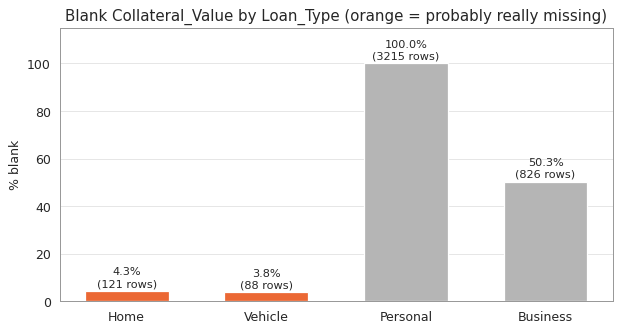

In [7]:
coll_blank = plot_df['Collateral_Value'].isnull()
coll_table = pd.DataFrame({
    'rows': plot_df.groupby('Loan_Type').size(),
    'blank_rows': coll_blank.groupby(plot_df['Loan_Type']).sum(),
})
coll_table['blank_percent'] = (coll_table['blank_rows'] / coll_table['rows'] * 100).round(1)
coll_table = coll_table.reindex(order['Loan_Type'])
print(coll_table)

plt.figure(figsize=(7, 3.8))
colors = []
for loan_type in coll_table.index:
    if coll_table.loc[loan_type, 'blank_percent'] < 10:
        colors.append(SECOND_COLOR)      # secured loan types with a few blanks -> really missing
    else:
        colors.append(MISSING_COLOR)
bars = plt.bar(coll_table.index, coll_table['blank_percent'], color=colors, width=0.6)
for bar, value, n in zip(bars, coll_table['blank_percent'], coll_table['blank_rows']):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 2, str(value) + '%\n(' + str(n) + ' rows)', ha='center', fontsize=9)
plt.ylim(0, 115)
plt.ylabel('% blank')
plt.title('Blank Collateral_Value by Loan_Type (orange = probably really missing)')
plt.gca().xaxis.grid(False)
save_plot('a2_collateral_blank_by_loan_type.png')

**Answer (P15) – Collateral_Value blanks:**

| Loan type | Blank | Meaning |
|---|---|---|
| Personal | **100%** (3,215) | Personal loans are always unsecured, so blank = **no collateral (0)** |
| Business | **50.3%** (826) | About half are secured. The blanks are most likely unsecured business loans |
| Home | **4.3%** (121) | A home loan always has a property, so these are **really missing** |
| Vehicle | **3.8%** (88) | A vehicle loan always has the vehicle, so these are **really missing** |

**For Phase 3:**
- Personal and Business blanks → **0** (unsecured). For Business, this is the cautious choice: we cannot be fully sure a blank means unsecured.
- Home and Vehicle blanks (209 rows) → **must be filled with an estimate**.

### A3. Odd tenures 10, 15, 20, 25, 30 (P13): which loan type?

In [8]:
tenure_table = pd.crosstab(plot_df['Loan_Tenure'], plot_df['Loan_Type'])[order['Loan_Type']]
tenure_table.index = tenure_table.index.astype(int)
print(tenure_table)

odd = plot_df[(plot_df['Loan_Tenure'] % 12 != 0) & plot_df['Loan_Tenure'].notnull()]
print()
print('Odd tenures by loan type:')
print(odd['Loan_Type'].value_counts())

Loan_Type    Home  Vehicle  Personal  Business
Loan_Tenure                                   
10             14        0         0         0
12              0      177       247       160
15             26        0         0         0
20             40        0         0         0
24              0      191       608       243
25             13        0         0         0
30              2        0         0         0
36              0      465       978       388
48              0      449       605       240
60              0      780       709       342
84              0      243         0       170
120           394        0         0        66
180           804        0         0         0
240           915        0         0         0
300           406        0         0         0
360           144        0         0         0

Odd tenures by loan type:
Loan_Type
Home    95
Name: count, dtype: int64


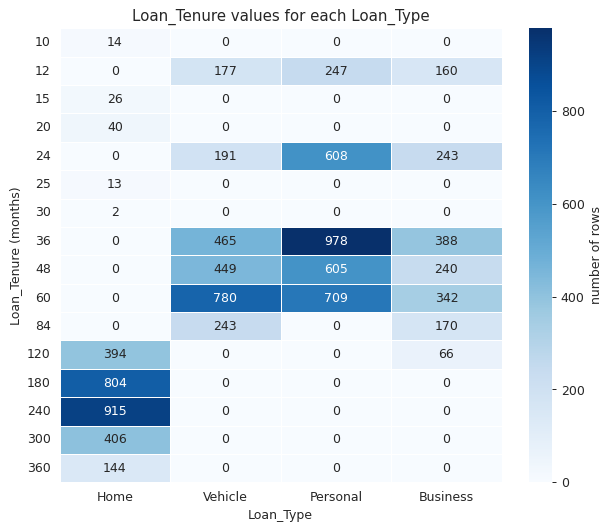

In [9]:
plt.figure(figsize=(7, 6))
sns.heatmap(tenure_table, annot=True, fmt='d', cmap='Blues', linewidths=0.5, cbar_kws={'label': 'number of rows'})
plt.title('Loan_Tenure values for each Loan_Type')
plt.ylabel('Loan_Tenure (months)')
plt.yticks(rotation=0)
save_plot('a3_tenure_by_loan_type.png')

**Answer (P13) – odd tenures:** **All 95 odd tenures (10, 15, 20, 25, 30) are Home loans.** Home loans otherwise only use 120–360 months, and 10/15/20/25/30 **× 12 = 120/180/240/300/360**.
**Conclusion: these are years typed instead of months.** Phase 3 should multiply them by 12. No other loan type has this problem.

### A4. Work_Experience vs Age (P08): is experience ever more than (age − 18)?

Rows where Work_Experience > Age - 18: 21
           Loan_ID   Age  Work_Experience Employment_Type
839   LN2025104340  32.0             37.0        Salaried
988   LN2025107399  30.0             33.0        Salaried
1006  LN2025103779  39.0             47.0        Salaried
1343  LN2025100556  43.0             50.0             SEP
1575  LN2025106054  36.0             45.0        Salaried
1686  LN2025107902  24.0             29.0        Salaried
1990  LN2025108130  37.0             40.0        Salaried
2330  LN2025108064  45.0             49.0             SEP


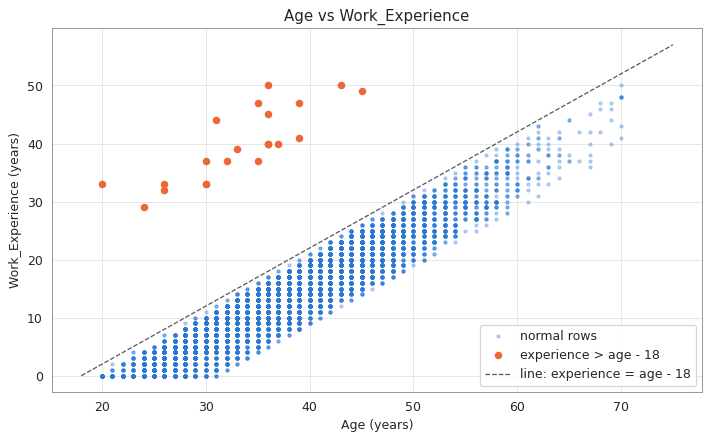

In [10]:
both = plot_df[plot_df['Age'].notnull() & plot_df['Work_Experience'].notnull()]
too_much = both[both['Work_Experience'] > both['Age'] - 18]
print('Rows where Work_Experience > Age - 18:', len(too_much))
print(too_much[['Loan_ID', 'Age', 'Work_Experience', 'Employment_Type']].head(8).to_string())

plt.figure(figsize=(8, 5))
plt.scatter(both['Age'], both['Work_Experience'], s=6, alpha=0.3, color=MAIN_COLOR, label='normal rows')
plt.scatter(too_much['Age'], too_much['Work_Experience'], s=25, color=SECOND_COLOR, label='experience > age - 18')
ages = np.arange(18, 76)
plt.plot(ages, ages - 18, color='#555555', linestyle='--', linewidth=1, label='line: experience = age - 18')
plt.xlabel('Age (years)')
plt.ylabel('Work_Experience (years)')
plt.title('Age vs Work_Experience')
plt.legend()
save_plot('a4_age_vs_experience.png')

**Answer (P08) – experience vs age:** **21 more rows** have experience greater than (age − 18), for example age 32 with 37 years of experience.
Phase 1 could not see these because each value looks fine on its own.
**For Phase 3:** treat these 21 values as invalid, together with the 25 found in Phase 1. In the scatter plot, all other points stay under the line.

### A5. Age ↔ Work_Experience correlation without the bad values

In [11]:
corr_raw = df['Age'].corr(df['Work_Experience'])
corr_clean_view = plot_df['Age'].corr(plot_df['Work_Experience'])
print('Correlation on raw data             : %.3f' % corr_raw)
print('Correlation with bad values hidden  : %.3f' % corr_clean_view)

Correlation on raw data             : 0.279
Correlation with bad values hidden  : 0.937


**Answer – Age ↔ Work_Experience correlation:** It was **0.279** on raw data but **0.937** once the bad values are hidden.
So the low value in Phase 1 was caused only by the bad values. **Age and Work_Experience carry almost the same information.** Note for Phase 4: keeping both may be redundant.

### A6. Loan_Amount and Collateral_Value by Loan_Type (where do the big values come from?)

In [12]:
q1 = plot_df['Loan_Amount'].quantile(0.25)
q3 = plot_df['Loan_Amount'].quantile(0.75)
upper_fence = q3 + 1.5 * (q3 - q1)
print('Loan_Amount IQR upper fence: Rs.', round(upper_fence))
print('Loan_Amount outliers by loan type:')
print(plot_df[plot_df['Loan_Amount'] > upper_fence]['Loan_Type'].value_counts())
print()
print('Median Loan_Amount by type:')
print(plot_df.groupby('Loan_Type')['Loan_Amount'].median().reindex(order['Loan_Type']))
print()
print('Median Collateral_Value by type (present values only):')
print(plot_df.groupby('Loan_Type')['Collateral_Value'].median().reindex(order['Loan_Type']))

Loan_Amount IQR upper fence: Rs. 4056250
Loan_Amount outliers by loan type:
Loan_Type
Home        822
Business     35
Name: count, dtype: int64

Median Loan_Amount by type:
Loan_Type
Home        2800000.0
Vehicle      420000.0
Personal     370000.0
Business     630000.0
Name: Loan_Amount, dtype: float64

Median Collateral_Value by type (present values only):
Loan_Type
Home        4260000.0
Vehicle      490000.0
Personal          NaN
Business    1215000.0
Name: Collateral_Value, dtype: float64


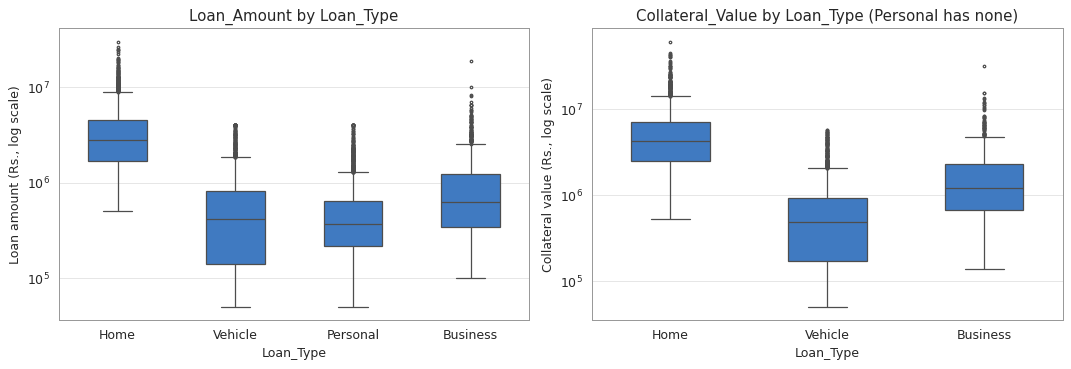

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.boxplot(data=plot_df, x='Loan_Type', y='Loan_Amount', order=order['Loan_Type'], color=MAIN_COLOR,
            width=0.5, ax=axes[0], flierprops={'markersize': 2})
axes[0].set_yscale('log')
axes[0].set_title('Loan_Amount by Loan_Type')
axes[0].set_ylabel('Loan amount (Rs., log scale)')

secured = plot_df[plot_df['Collateral_Value'].notnull()]
sns.boxplot(data=secured, x='Loan_Type', y='Collateral_Value', order=['Home', 'Vehicle', 'Business'], color=MAIN_COLOR,
            width=0.5, ax=axes[1], flierprops={'markersize': 2})
axes[1].set_yscale('log')
axes[1].set_title('Collateral_Value by Loan_Type (Personal has none)')
axes[1].set_ylabel('Collateral value (Rs., log scale)')
save_plot('a6_amount_collateral_by_loan_type.png')

**Answer – where the big values come from:**
- **822 of the 857 Loan_Amount outliers are Home loans** (the other 35 are Business loans). The median home loan is ₹28 lakh, compared with ₹3.7–6.3 lakh for the other types.
  These are **real large loans**, not errors. **Do not delete them in Phase 3.**
- The median collateral is ₹42.6 lakh for Home, ₹4.9 lakh for Vehicle and ₹12.2 lakh for Business.
  This explains the **two humps** seen in Phase 1: the small hump is vehicles and the big hump is property.

### A7. Are the small missing values random? (needed for Phase 3 imputation)
If missing values were linked to the decision, simple filling could add bias. We compare the approval rate of rows **with** and **without** a value, and use a chi-square test (p < 0.05 = probably a real difference).

In [14]:
missing_check = []
for col in ['Gender', 'Marital_Status', 'Dependents', 'Work_Experience', 'Monthly_Income',
            'Existing_EMI', 'CIBIL_Score', 'Loan_Amount', 'Loan_Tenure', 'Property_Area']:
    is_missing = df[col].isnull()
    table = pd.crosstab(is_missing, plot_df['approved'])
    chi2, p_value, dof, expected = chi2_contingency(table)
    missing_check.append({
        'column': col,
        'missing_rows': is_missing.sum(),
        'approval_when_missing_%': round(plot_df.loc[is_missing, 'approved'].mean() * 100, 1),
        'approval_when_present_%': round(plot_df.loc[~is_missing, 'approved'].mean() * 100, 1),
        'p_value': round(p_value, 3),
    })
missing_check = pd.DataFrame(missing_check)
missing_check

,column,missing_rows,approval_when_missing_%,approval_when_present_%,p_value
0,Gender,179,62.7,58.4,0.283
1,Marital_Status,118,62.7,58.4,0.399
2,Dependents,240,58.2,58.5,0.970
3,Work_Experience,301,55.8,58.6,0.370
4,Monthly_Income,99,63.6,58.4,0.346
5,Existing_EMI,252,56.0,58.6,0.446
6,CIBIL_Score,99,51.5,58.6,0.190
7,Loan_Amount,152,55.9,58.5,0.573
8,Loan_Tenure,181,67.4,58.3,0.017
9,Property_Area,149,59.1,58.5,0.952


**Answer – are the small missing values random?**
- For 9 of the 10 columns, the approval rate with and without a value is close, and **p > 0.05**.
- Only **Loan_Tenure** shows a difference (67.4% vs 58.3%, p = 0.017), and only for 181 rows. When we run 10 tests, one small p-value can easily appear by chance.
- **Conclusion: the small missing values look random (MCAR-like).** Simple filling (median or mode, maybe inside groups) is reasonable in Phase 3.

## Part B: Bivariate analysis – each column vs the target (Loan_Status)

### B1. Categorical columns vs Loan_Status

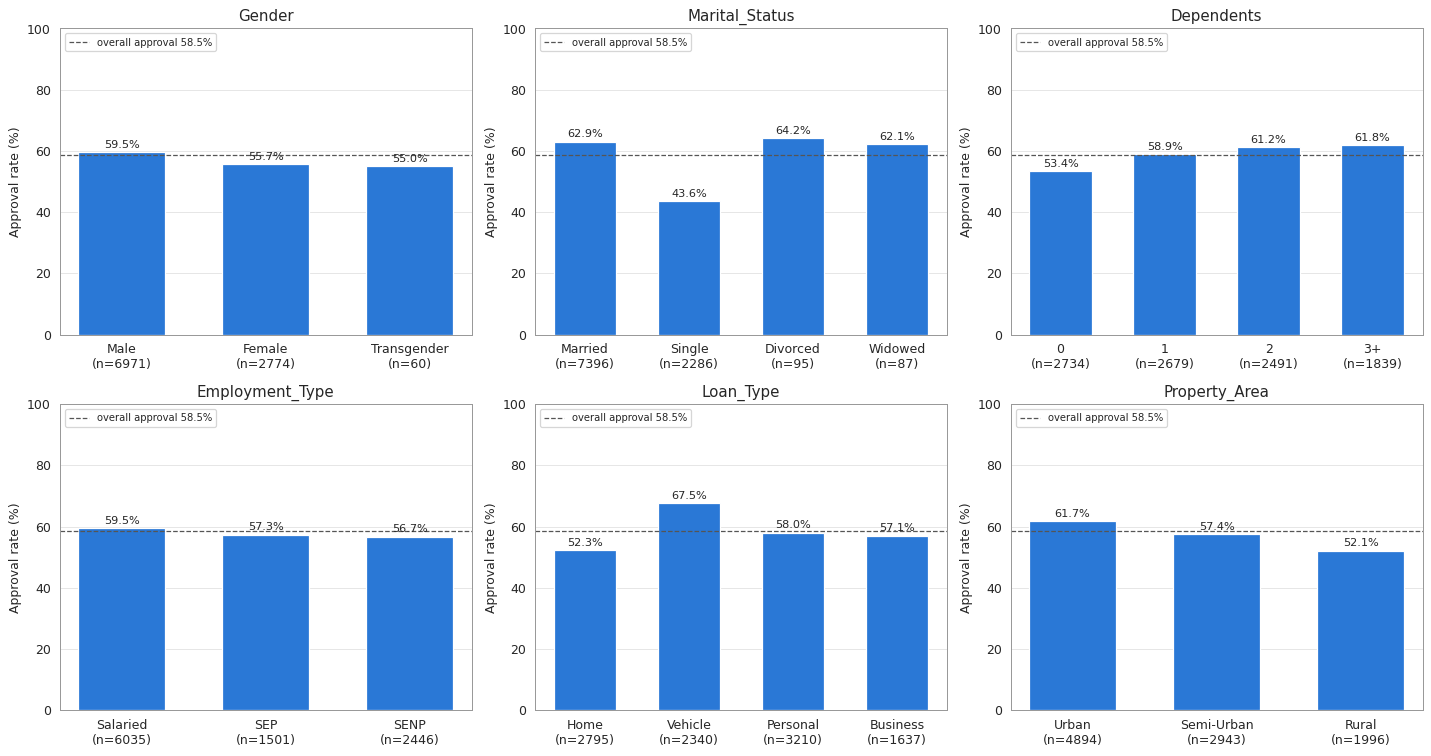

In [15]:
cat_cols = ['Gender', 'Marital_Status', 'Dependents', 'Employment_Type', 'Loan_Type', 'Property_Area']

fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
axes = axes.flatten()
for i in range(len(cat_cols)):
    col = cat_cols[i]
    draw_approval_bars(axes[i], plot_df[col], col, group_order=order[col])
save_plot('b1_categorical_vs_target.png')

In [16]:
# chi-square test: is the column related to Loan_Status?
chi_results = []
for col in cat_cols:
    table = pd.crosstab(plot_df[col], plot_df['Loan_Status'])
    chi2, p_value, dof, expected = chi2_contingency(table)
    rates = plot_df.groupby(col)['approved'].mean() * 100
    chi_results.append({
        'column': col,
        'chi2': round(chi2, 1),
        'p_value': p_value,
        'lowest_rate_%': round(rates.min(), 1),
        'highest_rate_%': round(rates.max(), 1),
        'gap_points': round(rates.max() - rates.min(), 1),
    })
chi_results = pd.DataFrame(chi_results).sort_values('chi2', ascending=False)
chi_results

,column,chi2,p_value,lowest_rate_%,highest_rate_%,gap_points
1,Marital_Status,270.8,2.065701e-58,43.6,64.2,20.6
4,Loan_Type,124.8,7.221717e-27,52.3,67.5,15.2
5,Property_Area,56.6,5.212819e-13,52.1,61.7,9.7
2,Dependents,45.0,9.399309e-10,53.4,61.8,8.4
0,Gender,12.2,2.217629e-03,55.0,59.5,4.5
3,Employment_Type,6.6,3.609646e-02,56.7,59.5,2.8


**Observation (categorical vs target):**

| Column | Lowest → highest approval | What it means |
|---|---|---|
| Marital_Status | Single **43.6%** → Divorced 64.2% (Married 62.9%) | Biggest gap (20.6 points). **But Part D6 shows this is mostly an age effect.** |
| Loan_Type | Home **52.3%** → Vehicle **67.5%** | Home loans are the hardest to get (big amounts, LTV rule) |
| Property_Area | Rural **52.1%** → Urban **61.7%** | Rural applicants earn less (see C2) |
| Dependents | 0 → **53.4%**, 3+ → 61.8% | Surprising: more dependents → *higher* approval. **D6 shows this is also age** |
| Gender | Transgender 55.0%, Female **55.7%** → Male **59.5%** | Gap of about 4 points. **Studied for fairness in D7** |
| Employment_Type | SENP 56.7% → Salaried 59.5% | Small gap |

All six are linked to the target (chi-square p < 0.05). Employment_Type is only just below 0.05, so it is the weakest.

### B2. CIBIL_Score vs Loan_Status (including −1 = no credit history)

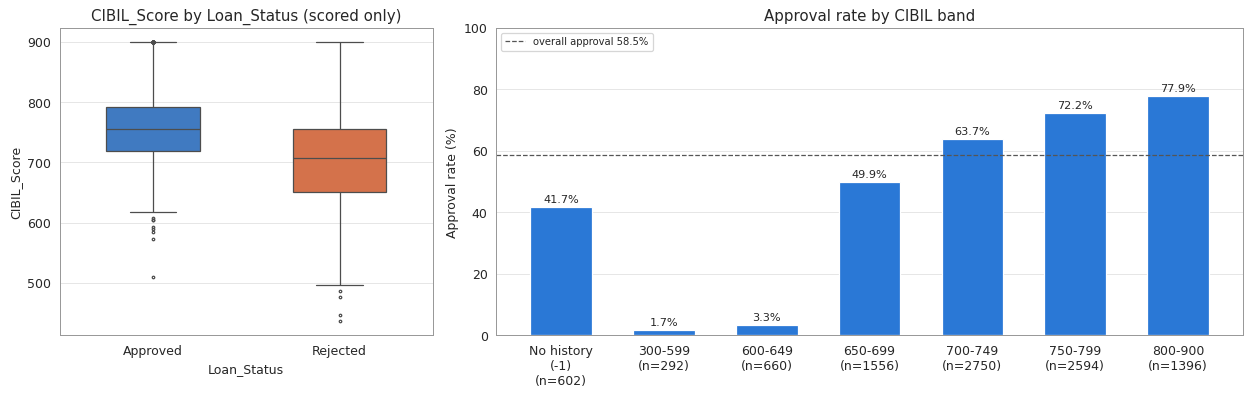

                  mean  count
CIBIL_Score                  
No history (-1)  0.417    602
300-599          0.017    292
600-649          0.033    660
650-699          0.499   1556
700-749          0.637   2750
750-799          0.722   2594
800-900          0.779   1396

Median CIBIL (scored) by status:
Loan_Status
Approved    755.0
Rejected    707.0
Name: CIBIL_Score, dtype: float64


In [17]:
cibil_groups = pd.cut(plot_df['CIBIL_Score'], bins=[299, 599, 649, 699, 749, 799, 900],
                      labels=['300-599', '600-649', '650-699', '700-749', '750-799', '800-900'])
cibil_groups = cibil_groups.astype(object)
cibil_groups[plot_df['CIBIL_Score'] == -1] = 'No history (-1)'
cibil_order = ['No history (-1)', '300-599', '600-649', '650-699', '700-749', '750-799', '800-900']

scored = plot_df[(plot_df['CIBIL_Score'] >= 300) & plot_df['Loan_Status'].notnull()]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={'width_ratios': [1, 2]})
sns.boxplot(data=scored, x='Loan_Status', y='CIBIL_Score', hue='Loan_Status', order=['Approved', 'Rejected'],
            palette=STATUS_COLORS, legend=False, width=0.5, ax=axes[0], flierprops={'markersize': 2})
axes[0].set_title('CIBIL_Score by Loan_Status (scored only)')
cibil_table = draw_approval_bars(axes[1], cibil_groups, 'Approval rate by CIBIL band', group_order=cibil_order)
save_plot('b2_cibil_vs_target.png')
print(cibil_table.round(3))
print()
print('Median CIBIL (scored) by status:')
print(scored.groupby('Loan_Status')['CIBIL_Score'].median())

**Observation (CIBIL):**
- This is the **strongest single column**. The median score is **755 for Approved** and **707 for Rejected**.
- There is a **sharp wall at 650**: scores 300–599 get **1.7%** approval and 600–649 get **3.3%**, but **650–699 jumps to 49.9%**, rising to **77.9% for 800+**.
  A wall like this suggests a **hard bank rule (CIBIL ≥ 650)**, not a smooth effect. This supports the rule engine planned for the project.
- **No credit history (−1): 41.7%.** That is lower than any band above 650, but much higher than below 650, so these applicants are **not** treated like bad scorers. This confirms −1 must be kept as its own group (P12).

### B3. Numerical columns vs Loan_Status
For each column: **left** = boxplot for Approved vs Rejected, **right** = approval rate for groups of values.
The groups are simple ranges chosen with domain knowledge (for example ₹15,000 is a common minimum income).

In [18]:
def numeric_vs_target(col, groups, group_order, file_name, y_label, log_y=False, box_only_positive=False):
    data = plot_df[plot_df['Loan_Status'].notnull() & plot_df[col].notnull()]
    if box_only_positive:
        data = data[data[col] > 0]   # zeros hide the shape of the box
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={'width_ratios': [1, 2]})
    sns.boxplot(data=data, x='Loan_Status', y=col, hue='Loan_Status', order=['Approved', 'Rejected'],
                palette=STATUS_COLORS, legend=False, width=0.5, ax=axes[0], flierprops={'markersize': 2})
    if log_y:
        axes[0].set_yscale('log')
    axes[0].set_ylabel(y_label)
    axes[0].set_title(col + ' by Loan_Status')
    if box_only_positive:
        axes[0].set_title(col + ' by Loan_Status (values > 0 only)')
    table = draw_approval_bars(axes[1], groups, 'Approval rate by ' + col + ' group', group_order=group_order)
    save_plot(file_name)
    medians = data.groupby('Loan_Status')[col].median()
    print('Median', col, '-> Approved:', medians['Approved'], '| Rejected:', medians['Rejected'])
    print(table.round(3))

#### Age

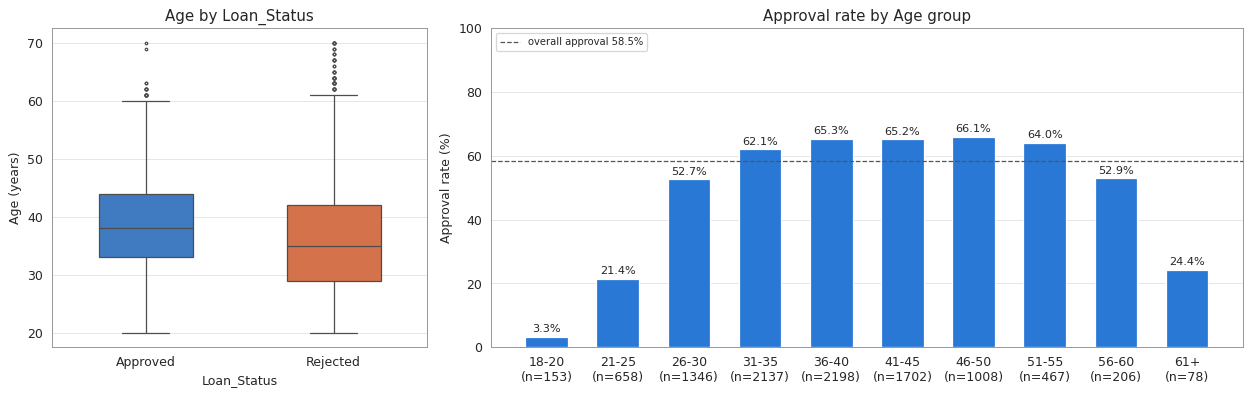

Median Age -> Approved: 38.0 | Rejected: 35.0
        mean  count
Age                
18-20  0.033    153
21-25  0.214    658
26-30  0.527   1346
31-35  0.621   2137
36-40  0.653   2198
41-45  0.652   1702
46-50  0.661   1008
51-55  0.640    467
56-60  0.529    206
61+    0.244     78


In [19]:
age_groups = pd.cut(plot_df['Age'], bins=[17, 20, 25, 30, 35, 40, 45, 50, 55, 60, 75],
                    labels=['18-20', '21-25', '26-30', '31-35', '36-40', '41-45', '46-50', '51-55', '56-60', '61+'])
numeric_vs_target('Age', age_groups, None, 'b3_age_vs_target.png', 'Age (years)')

**Observation (Age):**
- Approved applicants are a little older (median **38** vs **35**).
- **18–20 years: only 3.3% approval.** This is another **wall** and matches the bank minimum age of 21.
- Approval rises up to about 66% for ages 36–50, then **falls for 56–60 (52.9%) and 61+ (24.4%)**. Older applicants probably fail the **age-at-loan-end rule** (≤ 60 or 65), which depends on age **and** tenure together. This is a hint for Phase 4 (age at maturity).

#### Work_Experience

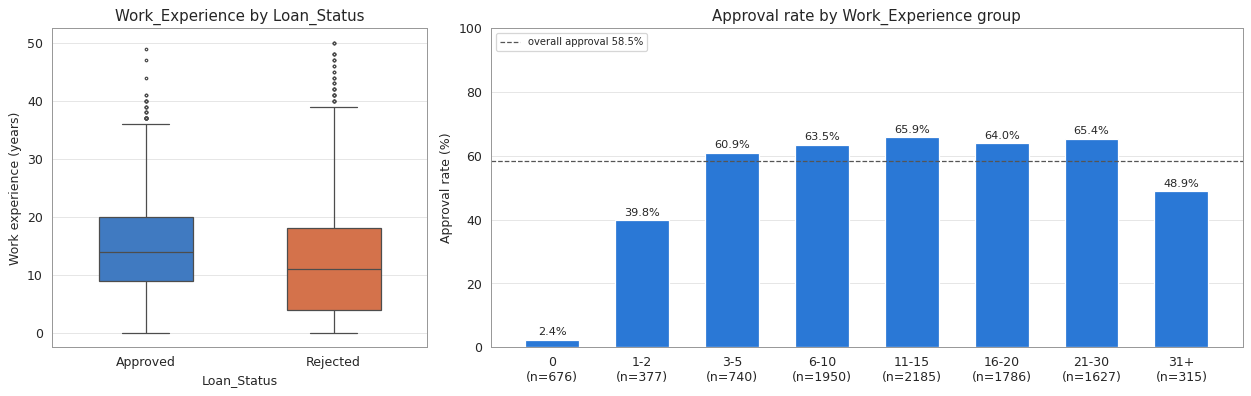

Median Work_Experience -> Approved: 14.0 | Rejected: 11.0
                  mean  count
Work_Experience              
0                0.024    676
1-2              0.398    377
3-5              0.609    740
6-10             0.635   1950
11-15            0.659   2185
16-20            0.640   1786
21-30            0.654   1627
31+              0.489    315


In [20]:
exp_groups = pd.cut(plot_df['Work_Experience'], bins=[-1, 0, 2, 5, 10, 15, 20, 30, 50],
                    labels=['0', '1-2', '3-5', '6-10', '11-15', '16-20', '21-30', '31+'])
numeric_vs_target('Work_Experience', exp_groups, None, 'b3_experience_vs_target.png', 'Work experience (years)')

In [21]:
# experience rules are different for salaried and self-employed people, so we split by Employment_Type
exp_small = pd.cut(plot_df['Work_Experience'], bins=[-1, 0, 2, 5, 50], labels=['0', '1-2', '3-5', '6+'])
print('Approval rate (%) by experience group and employment type')
print((pd.crosstab(exp_small, plot_df['Employment_Type'], values=plot_df['approved'], aggfunc='mean') * 100).round(1))

Approval rate (%) by experience group and employment type
Employment_Type  SENP   SEP  Salaried
Work_Experience                      
0                 2.6   1.3       2.7
1-2               1.5   3.9      62.4
3-5              57.7  65.8      60.6
6+               61.7  67.8      64.3


**Observation (Work_Experience):**
- **0 years: only 2.4% approval** (676 rows). This is another wall.
- 1–2 years: 39.8% approval, but the split by employment type explains it:
  - **Salaried with 1–2 years: 62.4%** (normal).
  - **Self-employed (SEP/SENP) with 1–2 years: only 1.5–3.9%.** From 3–5 years they reach about 58–66%.
  This matches the bank rule **"1 year for salaried, 3 years of business for self-employed"**. So **Work_Experience must be read together with Employment_Type.**
- 31+ years: 48.9% (these are older applicants, the same age effect as above).

#### Monthly_Income

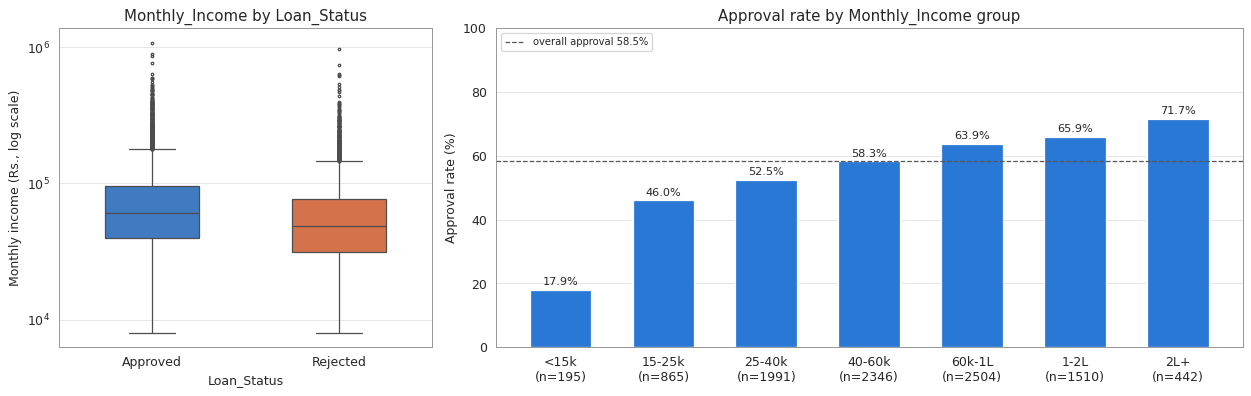

Median Monthly_Income -> Approved: 60600.0 | Rejected: 48600.0
                 mean  count
Monthly_Income              
<15k            0.179    195
15-25k          0.460    865
25-40k          0.525   1991
40-60k          0.583   2346
60k-1L          0.639   2504
1-2L            0.659   1510
2L+             0.717    442


In [22]:
income_groups = pd.cut(plot_df['Monthly_Income'], bins=[0, 15000, 25000, 40000, 60000, 100000, 200000, 2000000],
                       labels=['<15k', '15-25k', '25-40k', '40-60k', '60k-1L', '1-2L', '2L+'])
numeric_vs_target('Monthly_Income', income_groups, None, 'b3_income_vs_target.png', 'Monthly income (Rs., log scale)', log_y=True)

**Observation (Monthly_Income):**
- Approved applicants earn more (median **₹60,600** vs **₹48,600**).
- **Below ₹15,000: only 17.9%** approval. Above that, approval rises **smoothly** from 46% to 71.7% (₹2 lakh+).
  So income works both as a minimum rule and as a smooth "more is better" factor.

#### Coapplicant_Income

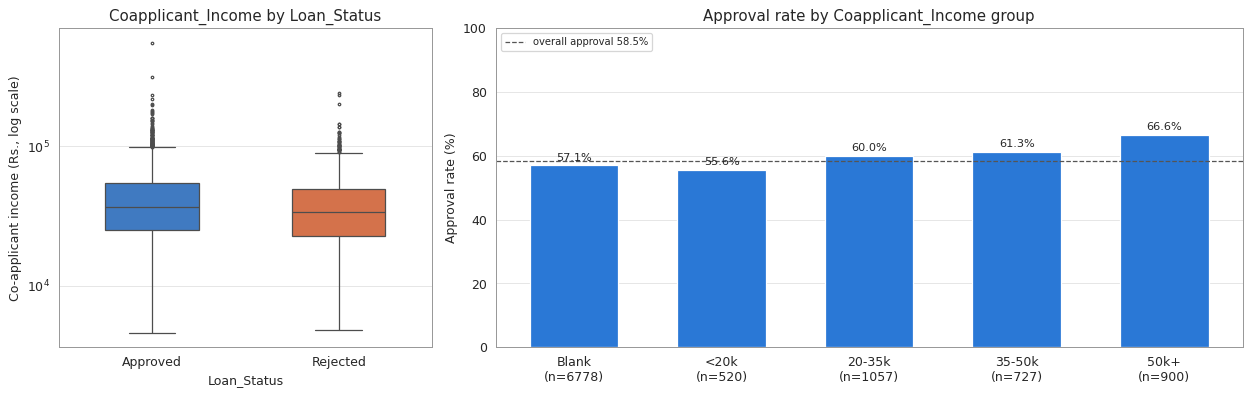

Median Coapplicant_Income -> Approved: 36700.0 | Rejected: 33600.0
                     mean  count
Coapplicant_Income              
Blank               0.571   6778
<20k                0.556    520
20-35k              0.600   1057
35-50k              0.613    727
50k+                0.666    900


In [23]:
co_groups = pd.cut(plot_df['Coapplicant_Income'], bins=[0, 20000, 35000, 50000, 1000000],
                   labels=['<20k', '20-35k', '35-50k', '50k+'])
co_groups = co_groups.astype(object)
co_groups[plot_df['Coapplicant_Income'].isnull()] = 'Blank'
numeric_vs_target('Coapplicant_Income', co_groups, ['Blank', '<20k', '20-35k', '35-50k', '50k+'],
                  'b3_coapplicant_vs_target.png', 'Co-applicant income (Rs., log scale)', log_y=True)

**Observation (Coapplicant_Income):**
- Blank (no co-applicant): 57.1% approval. Every group with a co-applicant earning ₹20k or more is higher (60.0–66.6%).
- Approval rises with co-applicant income: from 55.6% (below ₹20k) to **66.6% (₹50k+)**. Co-applicant income helps, which supports adding it to the applicant's income (total income) in Phase 4.

#### Existing_EMI

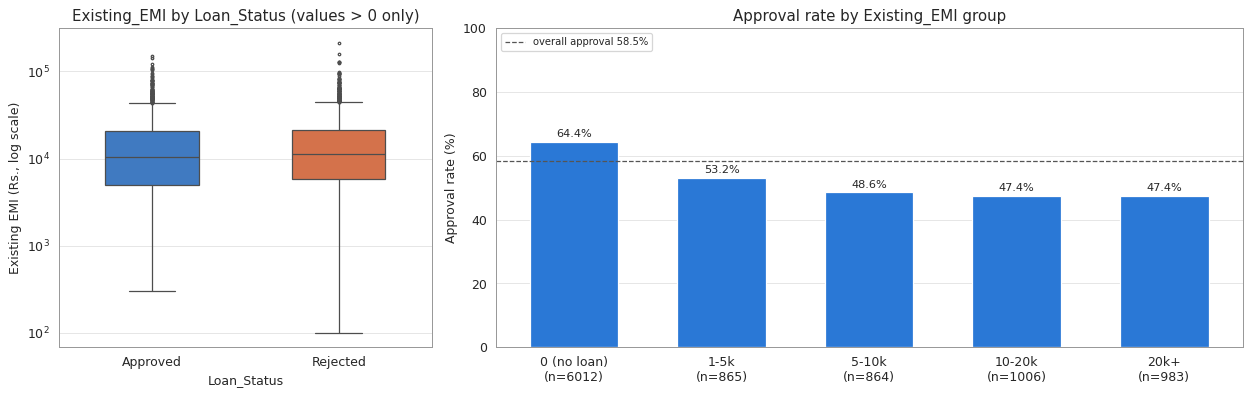

Median Existing_EMI -> Approved: 10400.0 | Rejected: 11300.0
               mean  count
Existing_EMI              
0 (no loan)   0.644   6012
1-5k          0.532    865
5-10k         0.486    864
10-20k        0.474   1006
20k+          0.474    983


In [24]:
emi_groups = pd.cut(plot_df['Existing_EMI'], bins=[-1, 0, 5000, 10000, 20000, 300000],
                    labels=['0 (no loan)', '1-5k', '5-10k', '10-20k', '20k+'])
numeric_vs_target('Existing_EMI', emi_groups, None, 'b3_emi_vs_target.png', 'Existing EMI (Rs., log scale)',
                  log_y=True, box_only_positive=True)

**Observation (Existing_EMI):**
- **No existing loan (EMI = 0): 64.4%** approval. **Any EMI: about 47–53%**. Applicants who already pay EMIs are approved less often.
- Above ₹5,000 the rate is almost flat (~47–49%). This suggests the size of the EMI **on its own** is not enough. What matters is the EMI **compared with income** (see D4).

#### Loan_Amount

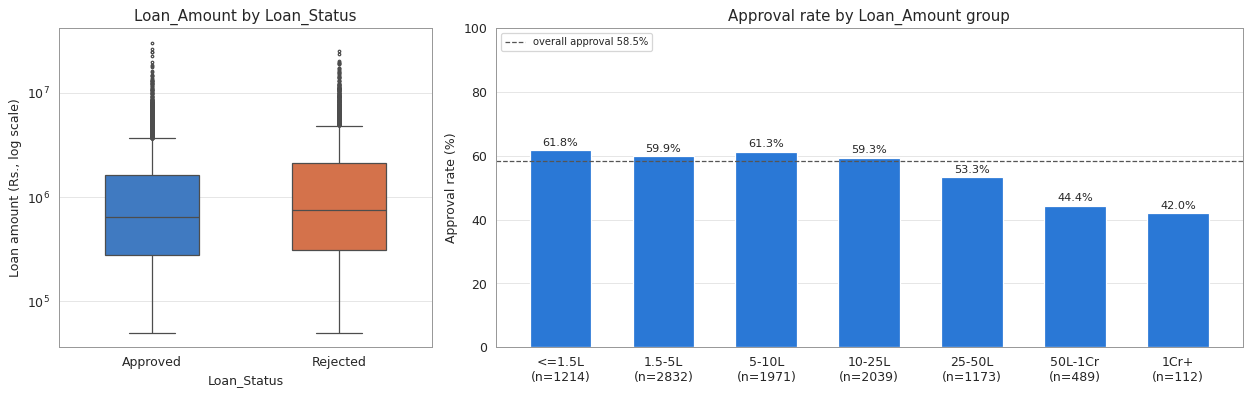

Median Loan_Amount -> Approved: 640000.0 | Rejected: 750000.0
              mean  count
Loan_Amount              
<=1.5L       0.618   1214
1.5-5L       0.599   2832
5-10L        0.613   1971
10-25L       0.593   2039
25-50L       0.533   1173
50L-1Cr      0.444    489
1Cr+         0.420    112


In [25]:
amount_groups = pd.cut(plot_df['Loan_Amount'], bins=[0, 150000, 500000, 1000000, 2500000, 5000000, 10000000, 40000000],
                       labels=['<=1.5L', '1.5-5L', '5-10L', '10-25L', '25-50L', '50L-1Cr', '1Cr+'])
numeric_vs_target('Loan_Amount', amount_groups, None, 'b3_amount_vs_target.png', 'Loan amount (Rs., log scale)', log_y=True)

**Observation (Loan_Amount):**
- Up to ₹25 lakh, approval stays around 59–62%. **It falls for big loans: 44.4% (₹50L–1Cr) and 42.0% (₹1Cr+)**.
- Rejected applicants ask for slightly more money (median **₹7.5 lakh** vs **₹6.4 lakh**).
- The effect is weak by itself, because a big loan is fine for a high earner. The loan size **compared with income** matters more (see D3).

#### Loan_Tenure

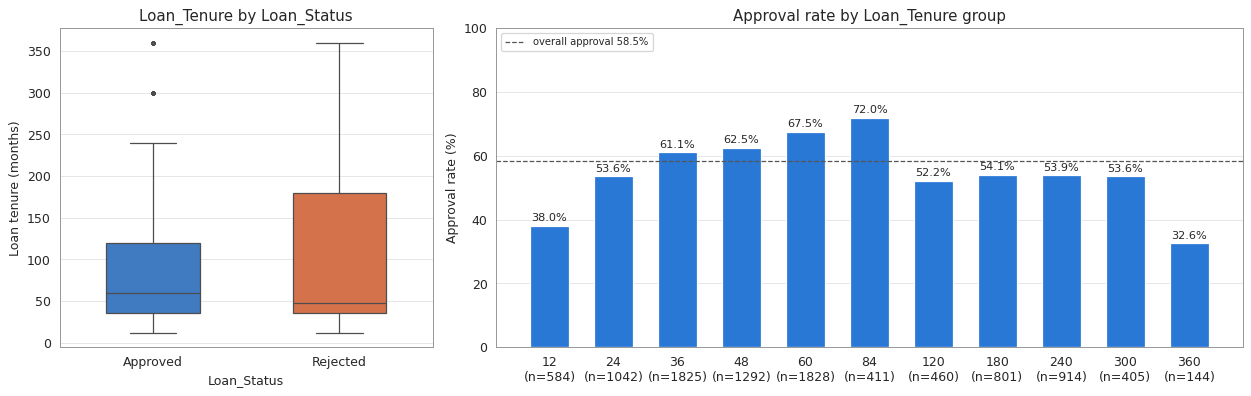

Median Loan_Tenure -> Approved: 60.0 | Rejected: 48.0
              mean  count
Loan_Tenure              
12           0.380    584
24           0.536   1042
36           0.611   1825
48           0.625   1292
60           0.675   1828
84           0.720    411
120          0.522    460
180          0.541    801
240          0.539    914
300          0.536    405
360          0.326    144


In [26]:
# A3 showed the 95 odd tenures are home loans typed in years. We hide them in the plot copy only.
# (The real fix, x12, is a Phase 3 job.)
plot_df.loc[plot_df['Loan_Tenure'] % 12 != 0, 'Loan_Tenure'] = np.nan
tenure_groups = plot_df['Loan_Tenure'].dropna().astype(int).astype(str)      # e.g. 36.0 -> '36'
tenure_order = ['12', '24', '36', '48', '60', '84', '120', '180', '240', '300', '360']
numeric_vs_target('Loan_Tenure', tenure_groups, tenure_order, 'b3_tenure_vs_target.png', 'Loan tenure (months)')

**Observation (Loan_Tenure, odd values hidden):**
- **12 months: only 38.0%.** A short tenure means a **big EMI**, so these applicants can fail the affordability (FOIR) check.
- **360 months: only 32.6%.** A 30-year loan often ends after age 60/65, so these applicants can fail the **age-at-loan-end rule**.
- 84 months has the highest approval (72.0%).
- Tenure is **not useful alone** (Spearman ≈ 0.02), but it matters together with **age** and **loan amount**. This is a strong hint for Phase 4 features (EMI / FOIR and age at maturity).

#### Collateral_Value

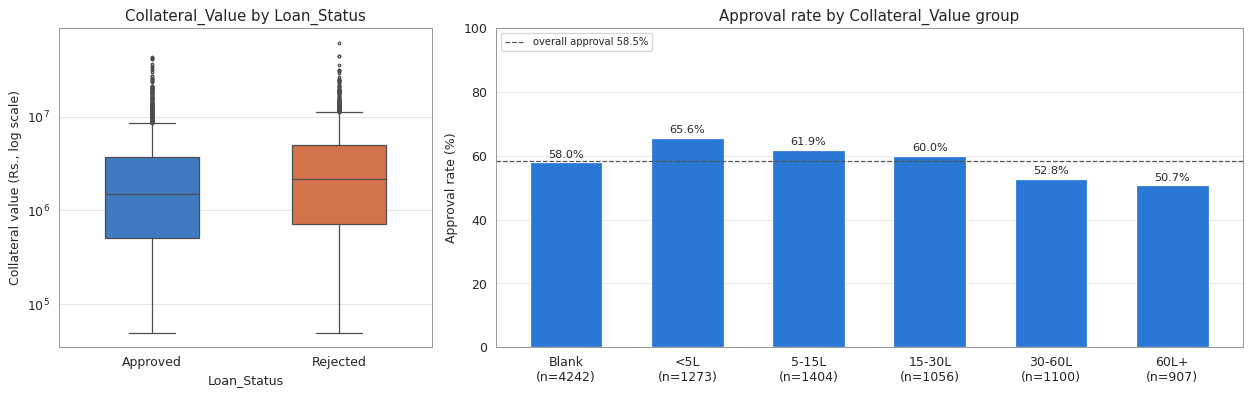

Median Collateral_Value -> Approved: 1480000.0 | Rejected: 2140000.0
                   mean  count
Collateral_Value              
Blank             0.580   4242
<5L               0.656   1273
5-15L             0.619   1404
15-30L            0.600   1056
30-60L            0.528   1100
60L+              0.507    907


In [27]:
coll_groups = pd.cut(plot_df['Collateral_Value'], bins=[0, 500000, 1500000, 3000000, 6000000, 100000000],
                     labels=['<5L', '5-15L', '15-30L', '30-60L', '60L+'])
coll_groups = coll_groups.astype(object)
coll_groups[plot_df['Collateral_Value'].isnull()] = 'Blank'
numeric_vs_target('Collateral_Value', coll_groups, ['Blank', '<5L', '5-15L', '15-30L', '30-60L', '60L+'],
                  'b3_collateral_vs_target.png', 'Collateral value (Rs., log scale)', log_y=True)

**Observation (Collateral_Value):**
- Bigger collateral goes with **lower** approval (65.6% below ₹5L down to 50.7% at ₹60L+). This looks odd, but bigger collateral simply means bigger **home loans**, which have the lowest approval.
- So collateral value **alone** is misleading. What matters is the collateral **compared with the loan** (the LTV rule, see D5).

### B4. Summary: how strongly is each numeric column linked to approval?

We use **Spearman correlation** with `approved` (1/0). Spearman works on ranks, so the skewed money columns are not a problem. CIBIL uses scored rows only.

Existing_EMI         -0.153
Collateral_Value     -0.116
Loan_Amount          -0.064
Loan_Tenure           0.017
Coapplicant_Income    0.078
Monthly_Income        0.156
Age                   0.159
Work_Experience       0.165
CIBIL_Score           0.366
Name: approved, dtype: float64


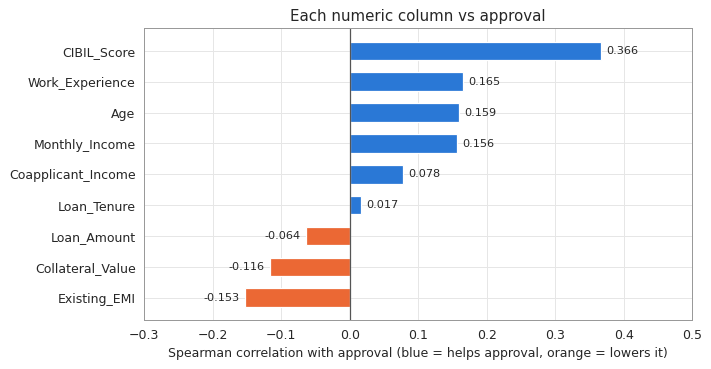

In [28]:
num_cols = ['Age', 'Work_Experience', 'Monthly_Income', 'Coapplicant_Income', 'Existing_EMI',
            'CIBIL_Score', 'Loan_Amount', 'Loan_Tenure', 'Collateral_Value']
num_table = plot_df[num_cols + ['approved']].copy()
num_table['CIBIL_Score'] = num_table['CIBIL_Score'].where(num_table['CIBIL_Score'] >= 300)   # -1 is not a score
num_table['Loan_Tenure'] = num_table['Loan_Tenure'].where(num_table['Loan_Tenure'] % 12 == 0)

target_corr = num_table.corr(method='spearman')['approved'].drop('approved').sort_values()
print(target_corr.round(3))

colors = []
for value in target_corr.values:
    if value >= 0:
        colors.append(MAIN_COLOR)
    else:
        colors.append(SECOND_COLOR)
plt.figure(figsize=(8, 4.2))
plt.barh(target_corr.index, target_corr.values, color=colors, height=0.6)
for i in range(len(target_corr)):
    value = target_corr.values[i]
    if value >= 0:
        plt.text(value + 0.008, i, str(round(value, 3)), va='center', fontsize=9)
    else:
        plt.text(value - 0.008, i, str(round(value, 3)), va='center', ha='right', fontsize=9)
plt.axvline(0, color='#555555', linewidth=1)
plt.xlim(-0.3, 0.5)
plt.xlabel('Spearman correlation with approval (blue = helps approval, orange = lowers it)')
plt.title('Each numeric column vs approval')
save_plot('b4_spearman_with_target.png')

**Observation (summary):**
- **CIBIL_Score (0.366)** is by far the strongest single link with approval.
- Work_Experience, Age and Monthly_Income come next (about 0.16 each).
- Existing_EMI (−0.153) and Collateral_Value (−0.116) work against approval. Loan_Amount (−0.064) and Loan_Tenure (0.017) are weak alone.
- **Every column except CIBIL is weak on its own.** Parts B3 and D show that many of them matter **in combination**, as ratios or rules. This is the main message for Phase 4.

## Part C: Bivariate analysis – columns vs each other

### C1. Correlation between numeric columns (bad values hidden)

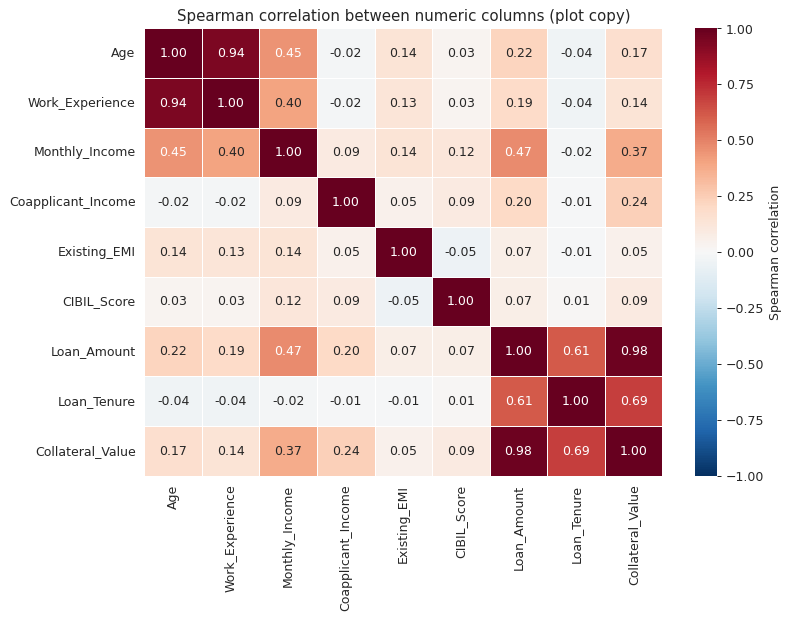

Pairs with |correlation| >= 0.5:
   Age <-> Work_Experience : 0.94
   Loan_Amount <-> Loan_Tenure : 0.61
   Loan_Amount <-> Collateral_Value : 0.98
   Loan_Tenure <-> Collateral_Value : 0.69


In [29]:
feature_corr = num_table.drop(columns='approved').corr(method='spearman').round(2)

plt.figure(figsize=(9, 7))
sns.heatmap(feature_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Spearman correlation'})
plt.title('Spearman correlation between numeric columns (plot copy)')
save_plot('c1_feature_correlation.png')

print('Pairs with |correlation| >= 0.5:')
for i in range(len(feature_corr.columns)):
    for j in range(i + 1, len(feature_corr.columns)):
        value = feature_corr.iloc[i, j]
        if abs(value) >= 0.5:
            print('  ', feature_corr.columns[i], '<->', feature_corr.columns[j], ':', value)

**Observation (column vs column):**
- **Age ↔ Work_Experience: 0.94** (almost the same information).
- **Loan_Amount ↔ Collateral_Value: 0.98** for secured loans. Collateral is basically the loan amount divided by the LTV, so the two are close copies.
- **Loan_Tenure ↔ Collateral_Value (0.69) and ↔ Loan_Amount (0.61).** Long tenures belong to big home loans.
- Monthly_Income ↔ Loan_Amount (0.47) and ↔ Age (0.45). Older people earn more and borrow more.
- **CIBIL_Score is almost independent of all other columns**, so it brings unique information.
- **For Phase 4:** strong pairs mean redundancy. Ratios such as collateral ÷ loan can replace the raw pair.

### C2. Monthly_Income by Employment_Type, Property_Area and Gender

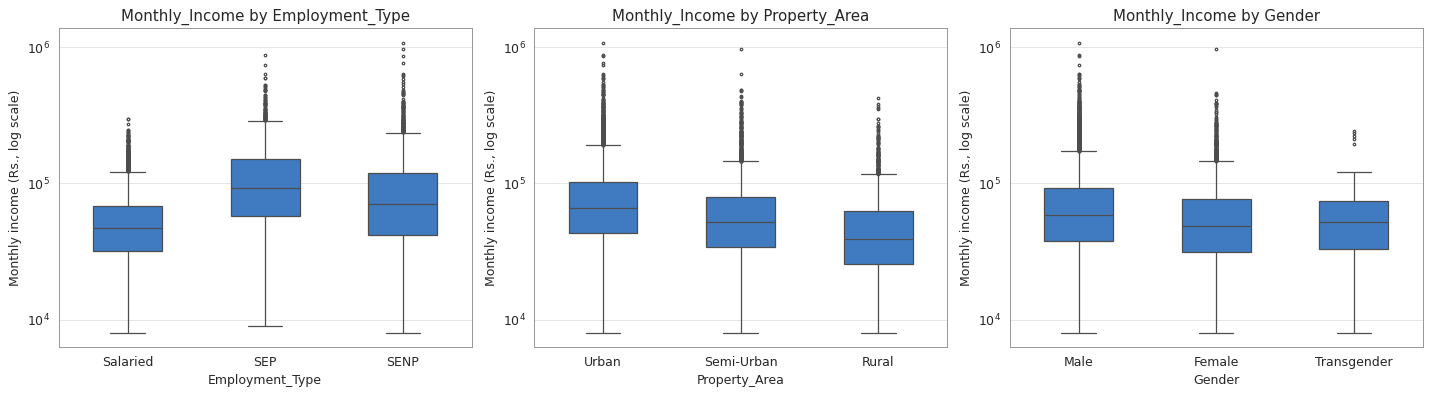

Median Monthly_Income by Employment_Type
Employment_Type
Salaried    46700.0
SEP         91650.0
SENP        69900.0
Name: Monthly_Income, dtype: float64

Median Monthly_Income by Property_Area
Property_Area
Urban         65400.0
Semi-Urban    51600.0
Rural         39100.0
Name: Monthly_Income, dtype: float64

Median Monthly_Income by Gender
Gender
Male           58100.0
Female         48500.0
Transgender    52200.0
Name: Monthly_Income, dtype: float64



In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for i, col in enumerate(['Employment_Type', 'Property_Area', 'Gender']):
    sns.boxplot(data=plot_df, x=col, y='Monthly_Income', order=order[col], color=MAIN_COLOR,
                width=0.5, ax=axes[i], flierprops={'markersize': 2})
    axes[i].set_yscale('log')
    axes[i].set_ylabel('Monthly income (Rs., log scale)')
    axes[i].set_title('Monthly_Income by ' + col)
save_plot('c2_income_by_groups.png')

for col in ['Employment_Type', 'Property_Area', 'Gender']:
    print('Median Monthly_Income by', col)
    print(plot_df.groupby(col)['Monthly_Income'].median().reindex(order[col]))
    print()

**Observation (income by groups):**
- **Employment:** SEP earn the most (median ₹91,650), then SENP (₹69,900), then Salaried (₹46,700).
- **Area:** Urban ₹65,400 > Semi-Urban ₹51,600 > Rural ₹39,100. This explains part of the lower rural approval.
- **Gender:** Male ₹58,100, Female ₹48,500, Transgender ₹52,200. There is an **income gap**, which explains part of the gender approval gap (checked in D7).

### C3. Employment_Type vs Loan_Type

Loan_Type        Home  Vehicle  Personal  Business
Employment_Type                                   
Salaried         30.3     25.4      42.6       1.6
SEP              30.9     20.0      19.9      29.2
SENP             20.5     20.5      13.8      45.2


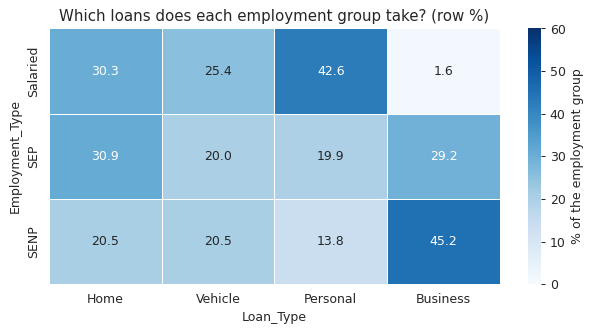

In [31]:
emp_loan = pd.crosstab(plot_df['Employment_Type'], plot_df['Loan_Type'], normalize='index') * 100
emp_loan = emp_loan.reindex(order['Employment_Type'])[order['Loan_Type']].round(1)
print(emp_loan)

plt.figure(figsize=(7, 3.8))
sns.heatmap(emp_loan, annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=60, linewidths=0.5,
            cbar_kws={'label': '% of the employment group'})
plt.title('Which loans does each employment group take? (row %)')
save_plot('c3_employment_vs_loan_type.png')

**Observation (employment vs loan type):**
- **Salaried** applicants mostly take **Personal (42.6%)** and Home loans, and almost never Business loans (1.6%).
- **SENP** applicants mostly take **Business loans (45.2%)**. SEP applicants are spread evenly.
- This is normal (business owners need business loans), but it means **employment type and loan type are linked**. Their effects on approval are mixed together, so D8 looks at them jointly.

### C4. Age by Marital_Status and Dependents

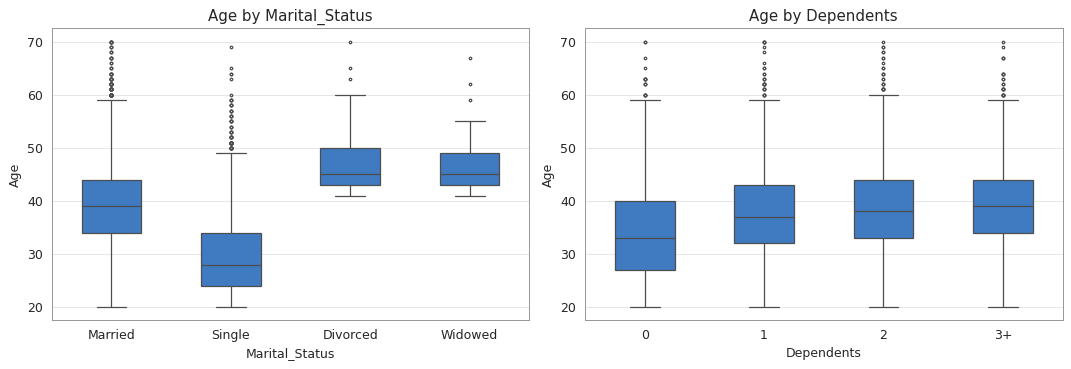

Median age by Marital_Status:
Marital_Status
Married     39.0
Single      28.0
Divorced    45.0
Widowed     45.0
Name: Age, dtype: float64

Median age by Dependents:
Dependents
0     33.0
1     37.0
2     38.0
3+    39.0
Name: Age, dtype: float64


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.boxplot(data=plot_df, x='Marital_Status', y='Age', order=order['Marital_Status'], color=MAIN_COLOR,
            width=0.5, ax=axes[0], flierprops={'markersize': 2})
axes[0].set_title('Age by Marital_Status')
sns.boxplot(data=plot_df, x='Dependents', y='Age', order=order['Dependents'], color=MAIN_COLOR,
            width=0.5, ax=axes[1], flierprops={'markersize': 2})
axes[1].set_title('Age by Dependents')
save_plot('c4_age_by_marital_dependents.png')

print('Median age by Marital_Status:')
print(plot_df.groupby('Marital_Status')['Age'].median().reindex(order['Marital_Status']))
print()
print('Median age by Dependents:')
print(plot_df.groupby('Dependents')['Age'].median().reindex(order['Dependents']))

**Observation (age by marital status and dependents):**
- **Single applicants are much younger** (median 28) than Married (39), Divorced or Widowed (45) applicants.
- Applicants with **0 dependents are younger** (median 33) than those with 3+ (median 39).
- Young applicants fail the age and experience rules more often (B3). So the "Single" and "0 dependents" gaps in B1 may really be **age** gaps. D6 checks this.

## Part D: Multivariate analysis (three or more columns together)

### D1. Pair plot of the main numeric columns, coloured by Loan_Status

A random sample of 1,500 rows is used so the plot is readable. Money columns are shown as log10 values **only in this plot**.

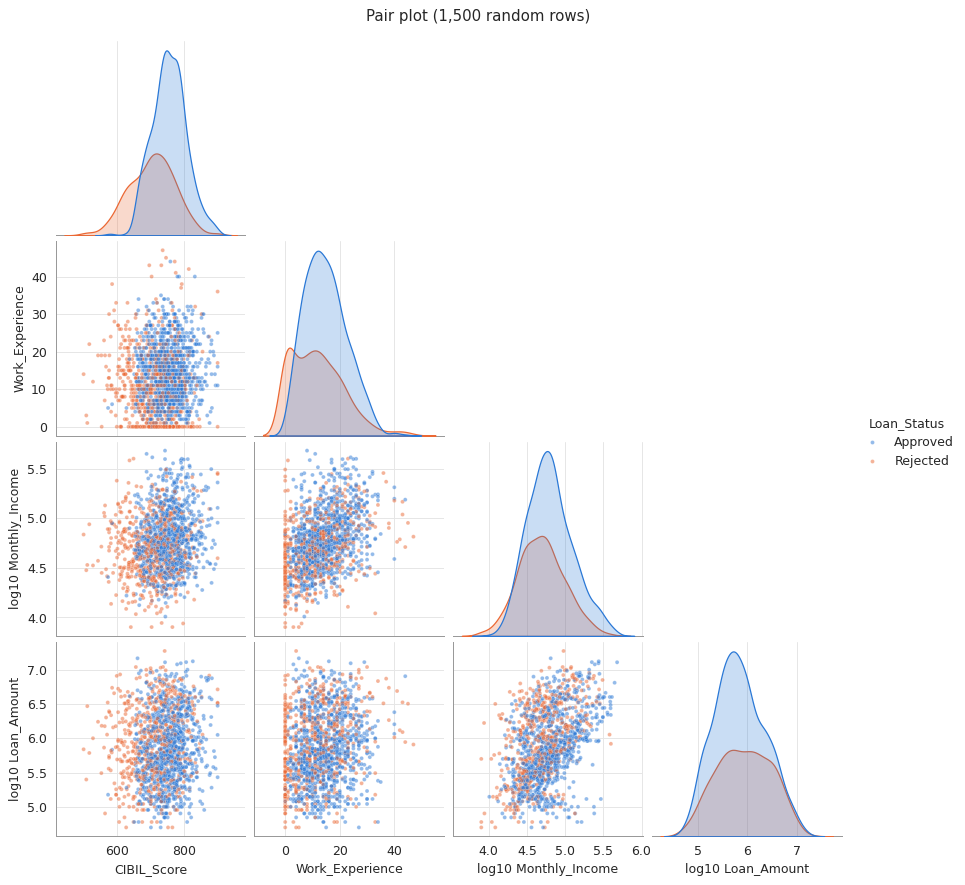

In [33]:
pair_data = plot_df[plot_df['Loan_Status'].notnull()].copy()
pair_data = pair_data[pair_data['CIBIL_Score'] >= 300]
pair_data = pair_data.dropna(subset=['Work_Experience', 'Monthly_Income', 'Loan_Amount'])
pair_data = pair_data.sample(1500, random_state=7)

pair_data['log10 Monthly_Income'] = np.log10(pair_data['Monthly_Income'])   # plot only
pair_data['log10 Loan_Amount'] = np.log10(pair_data['Loan_Amount'])         # plot only
pair_vars = ['CIBIL_Score', 'Work_Experience', 'log10 Monthly_Income', 'log10 Loan_Amount']

grid = sns.pairplot(pair_data, vars=pair_vars, hue='Loan_Status', hue_order=['Approved', 'Rejected'],
                    palette=STATUS_COLORS, corner=True, plot_kws={'s': 10, 'alpha': 0.5}, height=2.4)
grid.figure.suptitle('Pair plot (1,500 random rows)', y=1.02)
plt.savefig(os.path.join(PLOT_DIR, 'd1_pairplot.png'), dpi=130, bbox_inches='tight')
plt.show()

**Observation (pair plot):**
- **CIBIL_Score separates the classes best.** Below about 650 almost every point is orange (Rejected).
- **Work_Experience = 0** forms an orange line at the bottom of its plots.
- In **log income vs log loan amount**, rejected points sit more in the **upper-left** area (big loan for the income).
- No single plot separates the classes fully. **The decision depends on several columns together.**

### D2. CIBIL band × income band → approval rate

Income quartile edges (Rs.): [35500.0, 55300.0, 87900.0]


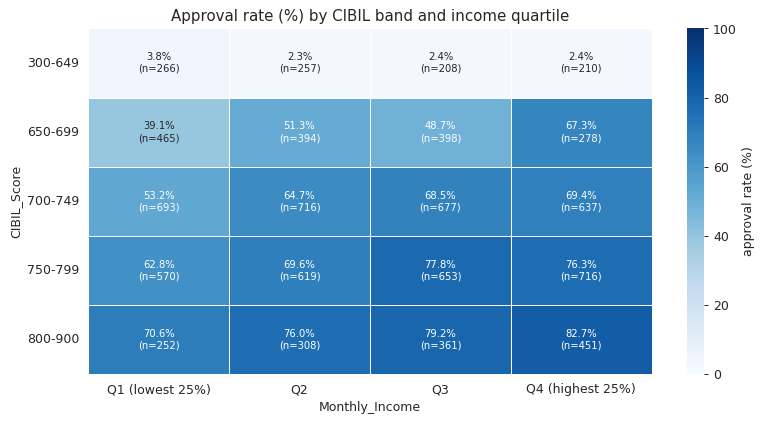

Monthly_Income,Q1 (lowest 25%),Q2,Q3,Q4 (highest 25%)
CIBIL_Score,,,,
300-649,3.8,2.3,2.4,2.4
650-699,39.1,51.3,48.7,67.3
700-749,53.2,64.7,68.5,69.4
750-799,62.8,69.6,77.8,76.3
800-900,70.6,76.0,79.2,82.7


In [34]:
cibil_band = pd.cut(plot_df['CIBIL_Score'], bins=[299, 649, 699, 749, 799, 900],
                    labels=['300-649', '650-699', '700-749', '750-799', '800-900'])
income_band = pd.qcut(plot_df['Monthly_Income'], 4, labels=['Q1 (lowest 25%)', 'Q2', 'Q3', 'Q4 (highest 25%)'])
print('Income quartile edges (Rs.):', plot_df['Monthly_Income'].quantile([0.25, 0.5, 0.75]).tolist())
approval_heatmap(cibil_band, income_band, 'Approval rate (%) by CIBIL band and income quartile',
                 'd2_cibil_income_heatmap.png', figsize=(9, 4.8))

**Observation (CIBIL × income):**
- **Below 650, approval is about 2–4% in every income group.** Even the richest applicants are rejected. So the CIBIL wall works like a **hard rule**.
- From 650 upward, **both** a higher score and a higher income raise approval: from 39.1% (650–699, lowest income) to 82.7% (800+, highest income).
- **Answer to Phase 1 question 9:** columns work **together**. A rule-based check plus a score-based model fits this data well.

### D3. Monthly_Income vs Loan_Amount for each Loan_Type (coloured by Loan_Status)

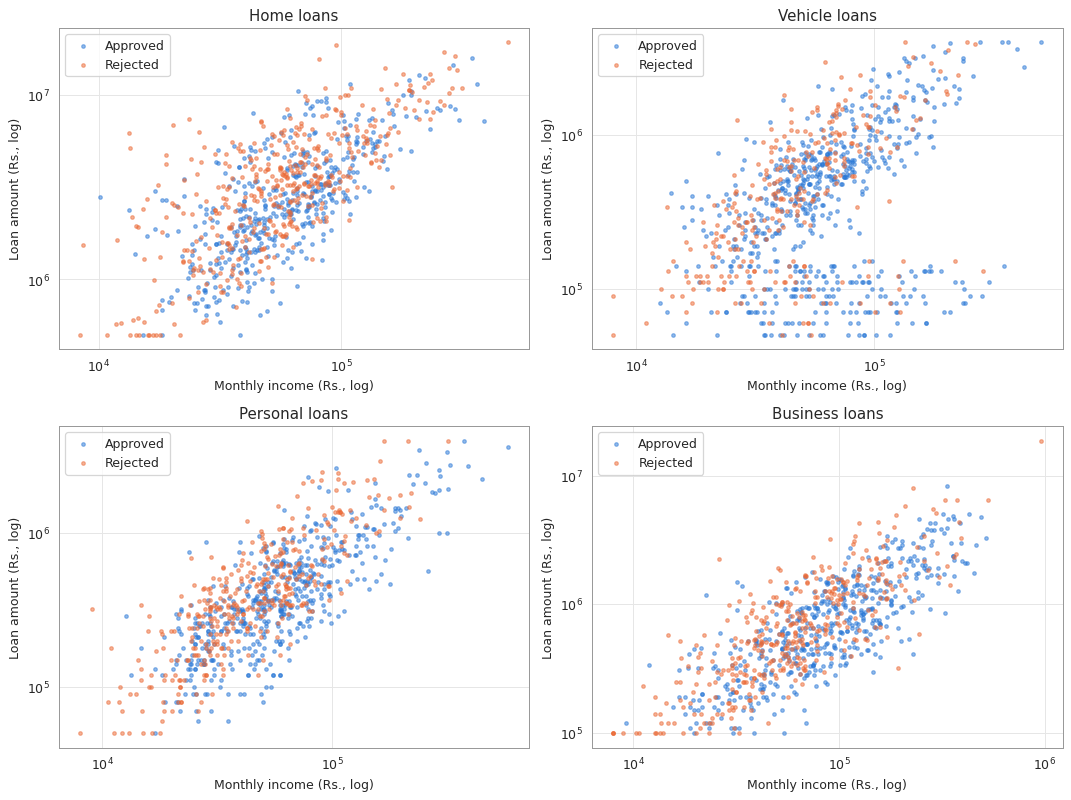

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
for i, loan_type in enumerate(order['Loan_Type']):
    part = plot_df[(plot_df['Loan_Type'] == loan_type) & plot_df['Loan_Status'].notnull()]
    part = part.dropna(subset=['Monthly_Income', 'Loan_Amount'])
    part = part.sample(min(900, len(part)), random_state=7)
    for status in ['Approved', 'Rejected']:
        rows = part[part['Loan_Status'] == status]
        axes[i].scatter(rows['Monthly_Income'], rows['Loan_Amount'], s=8, alpha=0.5,
                        color=STATUS_COLORS[status], label=status)
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')
    axes[i].set_title(loan_type + ' loans')
    axes[i].set_xlabel('Monthly income (Rs., log)')
    axes[i].set_ylabel('Loan amount (Rs., log)')
    axes[i].legend(loc='upper left')
save_plot('d3_income_vs_amount_by_type.png')

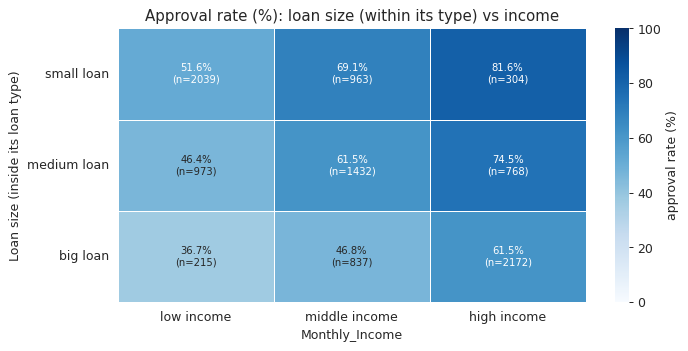

Monthly_Income,low income,middle income,high income
Loan size (inside its loan type),,,
small loan,51.6,69.1,81.6
medium loan,46.4,61.5,74.5
big loan,36.7,46.8,61.5


In [36]:
# same idea as a table: approval rate when income and loan amount are both low/high (within each loan type)
# loan sizes are very different for each loan type, so we split each type into 3 equal parts separately
amount_band = pd.Series(index=plot_df.index, dtype=object)
for loan_type in order['Loan_Type']:
    rows = plot_df['Loan_Type'] == loan_type
    amount_band[rows] = pd.qcut(plot_df.loc[rows, 'Loan_Amount'], 3,
                                labels=['small loan', 'medium loan', 'big loan']).astype(object)
amount_band.name = 'Loan size (inside its loan type)'
income_band3 = pd.qcut(plot_df['Monthly_Income'], 3, labels=['low income', 'middle income', 'high income'])
approval_heatmap(amount_band, income_band3, 'Approval rate (%): loan size (within its type) vs income',
                 'd3_amount_income_heatmap.png', row_order=['small loan', 'medium loan', 'big loan'], figsize=(8, 4))

**Observation (income × loan size):**
- In the scatter plots, rejected points (orange) sit **above** the approved cloud: **a big loan for the income**.
- In the table (loan size measured inside each loan type):
  - **small loan + high income: 81.6%**
  - **big loan + low income: 36.7%**
- For the **same income**, a bigger loan lowers approval. For the **same loan size**, a higher income raises approval.
- **What matters is the loan compared with the income, not either one alone.** This is direct evidence for **ratio features** in Phase 4, such as loan-to-income and EMI-to-income (FOIR).

### D4. Existing_EMI vs Monthly_Income (only applicants who already pay an EMI)

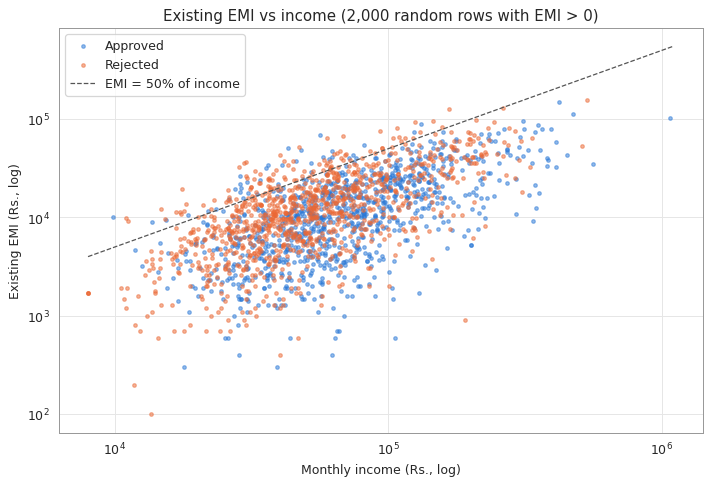

In [37]:
emi_rows = plot_df[(plot_df['Existing_EMI'] > 0) & plot_df['Loan_Status'].notnull()]
emi_rows = emi_rows.dropna(subset=['Monthly_Income'])
emi_rows = emi_rows.sample(2000, random_state=7)

plt.figure(figsize=(8, 5.5))
for status in ['Approved', 'Rejected']:
    rows = emi_rows[emi_rows['Loan_Status'] == status]
    plt.scatter(rows['Monthly_Income'], rows['Existing_EMI'], s=8, alpha=0.5, color=STATUS_COLORS[status], label=status)
incomes = np.array([8000, 1100000])
plt.plot(incomes, incomes * 0.5, color='#555555', linestyle='--', linewidth=1, label='EMI = 50% of income')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Monthly income (Rs., log)')
plt.ylabel('Existing EMI (Rs., log)')
plt.title('Existing EMI vs income (2,000 random rows with EMI > 0)')
plt.legend()
save_plot('d4_emi_vs_income.png')

**Observation (EMI × income):** For the same income, applicants with a **higher existing EMI** are more often rejected. Rejected points crowd near and above the "EMI = 50% of income" line.
Again, the **EMI compared with income** matters, not the EMI alone. This is the idea behind **FOIR** (Phase 4).

### D5. Home loans: Loan_Amount vs Collateral_Value with the RBI LTV limits
RBI allows a home loan of at most **90%** of the property value (loans up to ₹30 lakh), **80%** (₹30–75 lakh) and **75%** (above ₹75 lakh).
Here we only **compare** the loan with the allowed limit to see the pattern. No new column is saved.

Home loans checked: 2632
Loan above the RBI limit : 248
Approval rate above limit : 2.8%
Approval rate within limit: 57.1%


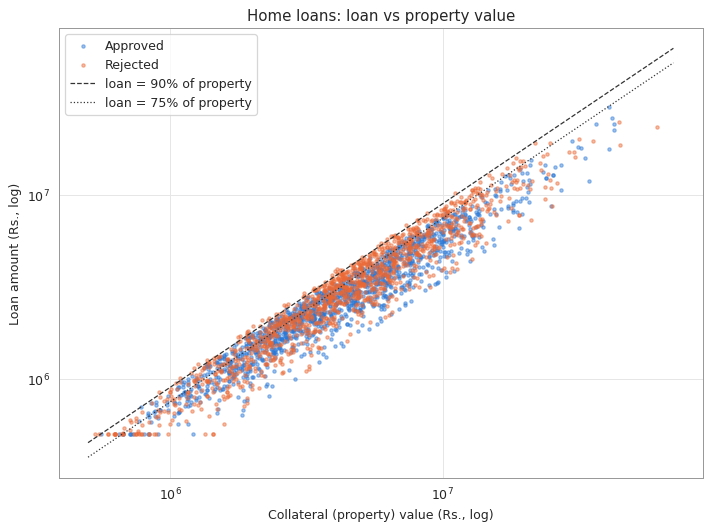

In [38]:
home = plot_df[(plot_df['Loan_Type'] == 'Home') & plot_df['Loan_Status'].notnull()]
home = home.dropna(subset=['Loan_Amount', 'Collateral_Value'])

allowed_percent = np.where(home['Loan_Amount'] <= 3000000, 0.90, np.where(home['Loan_Amount'] <= 7500000, 0.80, 0.75))
above_limit = home['Loan_Amount'] > allowed_percent * home['Collateral_Value']
print('Home loans checked:', len(home))
print('Loan above the RBI limit :', above_limit.sum())
print('Approval rate above limit : %.1f%%' % (home.loc[above_limit, 'approved'].mean() * 100))
print('Approval rate within limit: %.1f%%' % (home.loc[~above_limit, 'approved'].mean() * 100))

plt.figure(figsize=(8, 6))
for status in ['Approved', 'Rejected']:
    rows = home[home['Loan_Status'] == status]
    plt.scatter(rows['Collateral_Value'], rows['Loan_Amount'], s=7, alpha=0.45, color=STATUS_COLORS[status], label=status)
values = np.array([5e5, 7e7])
plt.plot(values, values * 0.90, color='#333333', linestyle='--', linewidth=1, label='loan = 90% of property')
plt.plot(values, values * 0.75, color='#333333', linestyle=':', linewidth=1, label='loan = 75% of property')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Collateral (property) value (Rs., log)')
plt.ylabel('Loan amount (Rs., log)')
plt.title('Home loans: loan vs property value')
plt.legend()
save_plot('d5_home_ltv_scatter.png')

**Observation (home loans and the RBI LTV limit):**
- **248 home loans ask for more than the RBI limit** (90% / 80% / 75% of the property value, depending on loan size).
- Their approval is only **2.8%**, compared with **57.1%** for loans within the limit.
- This is another **hard-rule wall**, and it matches the RBI rule exactly. A few of these loans (2.8%) were still approved. These look like **past exceptions**, which the planned rule engine should block.

### D6. Marital_Status × age group → approval rate (is the Single gap really about age?)

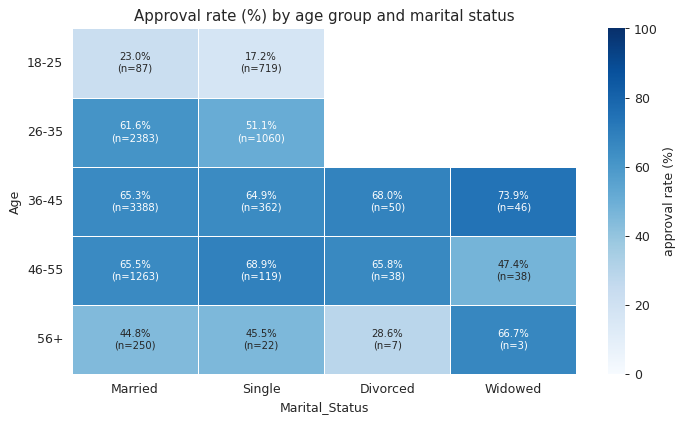

Marital_Status,Married,Single,Divorced,Widowed
Age,,,,
18-25,23.0,17.2,NaN,NaN
26-35,61.6,51.1,NaN,NaN
36-45,65.3,64.9,68.0,73.9
46-55,65.5,68.9,65.8,47.4
56+,44.8,45.5,28.6,66.7


In [39]:
age_band = pd.cut(plot_df['Age'], bins=[17, 25, 35, 45, 55, 75], labels=['18-25', '26-35', '36-45', '46-55', '56+'])
approval_heatmap(age_band, plot_df['Marital_Status'], 'Approval rate (%) by age group and marital status',
                 'd6_marital_age_heatmap.png', col_order=order['Marital_Status'], figsize=(8, 4.8))

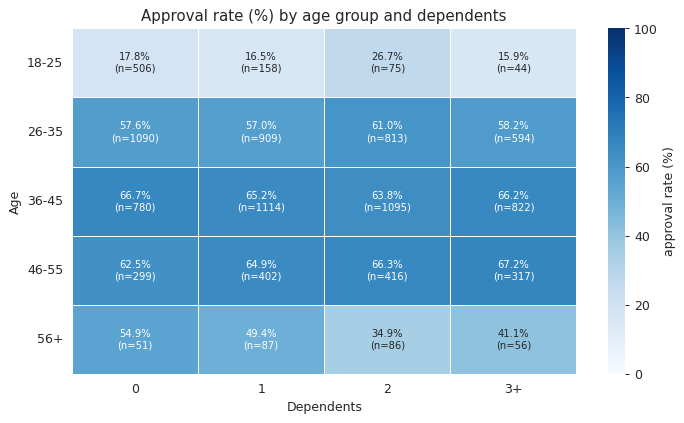

Dependents,0,1,2,3+
Age,,,,
18-25,17.8,16.5,26.7,15.9
26-35,57.6,57.0,61.0,58.2
36-45,66.7,65.2,63.8,66.2
46-55,62.5,64.9,66.3,67.2
56+,54.9,49.4,34.9,41.1


In [40]:
approval_heatmap(age_band, plot_df['Dependents'], 'Approval rate (%) by age group and dependents',
                 'd6_dependents_age_heatmap.png', col_order=order['Dependents'], figsize=(8, 4.8))

**Observation (marital status and dependents inside age groups):**
- Inside the same age group, **Married and Single are close**:
  - 36–45: 65.3% vs 64.9%
  - 46–55: Single is even higher (68.9% vs 65.5%)
- The big overall gap (62.9% vs 43.6%) comes mainly from **719 of the 806 applicants aged 18–25 being Single**, and young applicants fail the age and experience rules.
- **Dependents** show no clear pattern inside an age group either. **So Marital_Status and Dependents look like "age in disguise".**
- A gap of about 10 points remains for ages 26–35 (61.6% vs 51.1%). This is a **confounding** effect, not proof that being single causes rejection.

### D7. Fairness first look: Gender × income quartile → approval rate

This is only to **describe** the data for the fairness audit. Gender must not be used as a model input.

Gender            Male  Female  Transgender
Monthly_Income                             
Q1 (lowest 25%)   49.2    44.7         38.9
Q2                57.4    55.9         56.2
Q3                62.5    61.8         71.4
Q4 (highest 25%)  67.0    66.2         54.5

Rows in each cell:
Gender            Male  Female  Transgender
Monthly_Income                             
Q1 (lowest 25%)   1563     855           18
Q2                1673     728           16
Q3                1796     608           14
Q4 (highest 25%)  1860     539           11


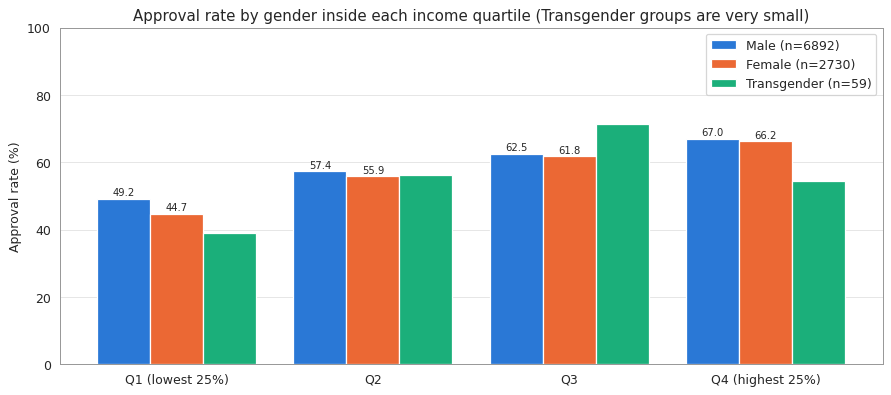


Overall approval by gender (%):
Gender
Male           59.5
Female         55.7
Transgender    55.0
Name: approved, dtype: float64
Female / Male approval ratio: 0.936


In [41]:
gender_income = pd.crosstab(income_band, plot_df['Gender'], values=plot_df['approved'], aggfunc='mean') * 100
gender_income = gender_income[order['Gender']].round(1)
gender_count = pd.crosstab(income_band, plot_df['Gender'], values=plot_df['approved'], aggfunc='count')[order['Gender']]
print(gender_income)
print()
print('Rows in each cell:')
print(gender_count)

x = np.arange(len(gender_income.index))
width = 0.27
gender_colors = {'Male': MAIN_COLOR, 'Female': SECOND_COLOR, 'Transgender': THIRD_COLOR}
plt.figure(figsize=(10, 4.5))
for k, gender in enumerate(order['Gender']):
    n_total = int(gender_count[gender].sum())
    plt.bar(x + (k - 1) * width, gender_income[gender], width=width, color=gender_colors[gender],
            label=gender + ' (n=' + str(n_total) + ')')
for k, gender in enumerate(['Male', 'Female']):
    for i in range(len(x)):
        value = gender_income[gender].iloc[i]
        plt.text(x[i] + (k - 1) * width, value + 1, str(value), ha='center', fontsize=8)
plt.xticks(x, gender_income.index)
plt.ylim(0, 100)
plt.ylabel('Approval rate (%)')
plt.title('Approval rate by gender inside each income quartile (Transgender groups are very small)')
plt.legend()
plt.gca().xaxis.grid(False)
save_plot('d7_gender_income_approval.png')

overall_gender = plot_df.groupby('Gender')['approved'].mean() * 100
print()
print('Overall approval by gender (%):')
print(overall_gender.reindex(order['Gender']).round(1))
print('Female / Male approval ratio: %.3f' % (overall_gender['Female'] / overall_gender['Male']))

**Observation (fairness first look – gender inside income quartiles):**
- **Overall:** Female 55.7% vs Male 59.5%, a ratio of **0.936**. This is above the common "80% rule" for fairness (0.8), but it is still a gap.
- Women earn less (C2), so part of the gap comes from income. But **inside every income quartile, women are still approved a little less** (by 0.7 to 4.5 points).
- So **income does not explain the whole gap**. The fairness audit must check this again on the model's predictions.
- Transgender applicants are only 59 rows (11–18 per group), so their numbers jump around and **cannot be trusted** for conclusions.

### D8. Employment_Type × Loan_Type → approval rate

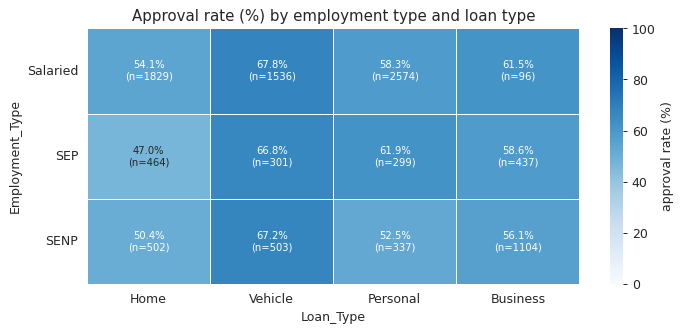

Loan_Type,Home,Vehicle,Personal,Business
Employment_Type,,,,
Salaried,54.1,67.8,58.3,61.5
SEP,47.0,66.8,61.9,58.6
SENP,50.4,67.2,52.5,56.1


In [42]:
approval_heatmap(plot_df['Employment_Type'], plot_df['Loan_Type'], 'Approval rate (%) by employment type and loan type',
                 'd8_employment_loan_heatmap.png', row_order=order['Employment_Type'], col_order=order['Loan_Type'],
                 figsize=(8, 3.8))

**Observation (employment × loan type):**
- **Home loans have the lowest approval for every employment group** (47.0–54.1%), and **Vehicle loans the highest** (66.8–67.8%).
- Loan type matters more than employment type. Inside the same loan type, employment groups differ by only a few points.

## Part E: Summary of Phase 2 and hand-over

In [43]:
check_df = pd.read_csv(DATA_PATH)
print('Real data (df) still the same as the raw file:', df.equals(check_df))
print('Shape:', df.shape)

Real data (df) still the same as the raw file: True
Shape: (10000, 17)


### Phase 2 summary

**Answers to the Phase 1 questions**

| Phase 1 question | Answer |
|---|---|
| 1. Coapplicant_Income blanks (P14) | Blank = **no earning co-applicant** → fill with 0 (Phase 3) |
| 2. Collateral_Value blanks (P15) | Personal 100% blank and Business 50% blank = **unsecured** (0). Home 121 + Vehicle 88 = **really missing** |
| 3. Odd tenures (P13) | **All 95 are home loans typed in years** → ×12 (Phase 3) |
| 4. Experience > age − 18 (P08) | **21 more invalid rows** → treat as missing (Phase 3) |
| 5. Age ↔ Work_Experience | **0.937** once bad values are hidden → nearly redundant |
| 6. Big amounts and collateral | Big loans are **home loans**. The collateral humps are **vehicles vs property** → real values, keep them |
| 7. Columns vs approval | CIBIL is strongest. Walls at **CIBIL < 650, age 20, 0 experience, income < ₹15k, LTV above the RBI limit** |
| 8. Fairness first look | Female/Male approval ratio **0.936**. The gap remains inside every income group |
| 9. Combined effects | **Ratios matter**: loan vs income, EMI vs income, loan vs collateral, age + tenure |

The real data frame `df` was not changed.